In [1]:
import pandas as pd
import matplotlib.pyplot as plt



## Belczysnki

    Z_over_Zsun            CE          RLOF  RLOF_highIMF  \
0          0.02  6.200000e-05  1.900000e-05  1.700000e-05   
1          0.05  5.500000e-05  1.800000e-05  1.600000e-05   
2          0.10  3.000000e-05  1.500000e-05  1.450000e-05   
3          0.15  2.300000e-05  1.300000e-05  1.200000e-05   
4          0.20  1.500000e-05  1.000000e-05  1.050000e-05   
5          0.30  8.500000e-06  6.000000e-06  7.500000e-06   
6          0.40  5.000000e-06  5.000000e-06  5.500000e-06   
7          0.50  3.200000e-06  4.500000e-06  4.800000e-06   
8          0.65  1.200000e-06  3.500000e-06  3.800000e-06   
9          0.75  4.000000e-07  7.000000e-06  6.000000e-06   
10         0.90  1.200000e-07  5.500000e-06  4.500000e-06   
11         1.05  4.000000e-08  3.500000e-06  2.700000e-06   
12         1.20  1.500000e-08  2.300000e-06  1.700000e-06   
13         1.40  5.000000e-09  1.100000e-06  8.000000e-07   
14         1.70  1.000000e-09  4.000000e-07  3.000000e-07   
15         2.00  3.00000

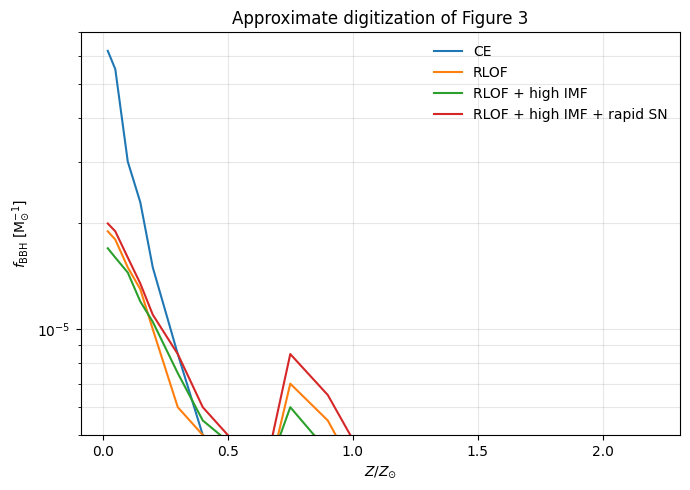

In [2]:
# Rough visual digitization of Figure 3 from:
# Belczynski et al. 2022, ApJ, 935, 126
# Figure 3: BH-BH merger formation efficiency per unit mass vs metallicity (Z / Zsun)
#
# IMPORTANT:
# - x-axis is Z / Zsun
# - y-axis is f_BBH [Msun^-1]
# - values below are approximate, visually digitized from the figure
# - intended for rough comparisons / plotting, not precision recovery
# https://iopscience.iop.org/article/10.3847/1538-4357/ac8167/pdf
# final points (highest Z might not be entirely accurate)
data = {
    "Z_over_Zsun": [
        0.02, 0.05, 0.10, 0.15, 0.20,
        0.30, 0.40, 0.50, 0.65, 0.75,
        0.90, 1.05, 1.20, 1.40, 1.70,
        2.00, 2.20
    ],
    "CE": [
        6.2e-5, 5.5e-5, 3.0e-5, 2.3e-5, 1.5e-5,
        8.5e-6, 5.0e-6, 3.2e-6, 1.2e-6, 4.0e-7,
        1.2e-7, 4.0e-8, 1.5e-8, 5.0e-9, 1.0e-9,
        3.0e-10, 1.0e-10
    ],
    "RLOF": [
        1.9e-5, 1.8e-5, 1.5e-5, 1.3e-5, 1.0e-5,
        6.0e-6, 5.0e-6, 4.5e-6, 3.5e-6, 7.0e-6,
        5.5e-6, 3.5e-6, 2.3e-6, 1.1e-6, 4.0e-7,
        1.2e-7, 5.0e-8
    ],
    "RLOF_highIMF": [
        1.7e-5, 1.6e-5, 1.45e-5, 1.2e-5, 1.05e-5,
        7.5e-6, 5.5e-6, 4.8e-6, 3.8e-6, 6.0e-6,
        4.5e-6, 2.7e-6, 1.7e-6, 8.0e-7, 3.0e-7,
        1.0e-7, 4.0e-8
    ],
    "RLOF_highIMF_rapidSN": [
        2.0e-5, 1.9e-5, 1.6e-5, 1.35e-5, 1.1e-5,
        8.5e-6, 6.0e-6, 5.0e-6, 4.0e-6, 8.5e-6,
        6.5e-6, 4.2e-6, 2.8e-6, 1.3e-6, 5.0e-7,
        1.5e-7, 6.0e-8
    ],
}

df = pd.DataFrame(data)

print(df)

# Optional: save
df.to_csv("figure3_digitized_corrected.csv", index=False)

# Plot
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(df["Z_over_Zsun"], df["CE"], label="CE")
ax.plot(df["Z_over_Zsun"], df["RLOF"], label="RLOF")
ax.plot(df["Z_over_Zsun"], df["RLOF_highIMF"], label="RLOF + high IMF")
ax.plot(df["Z_over_Zsun"], df["RLOF_highIMF_rapidSN"], label="RLOF + high IMF + rapid SN")

ax.set_yscale("log")
ax.set_xlabel(r"$Z/Z_{\odot}$")
ax.set_ylabel(r"$f_{\rm BBH}\ [{\rm M}_{\odot}^{-1}]$")
ax.set_title("Approximate digitization of Figure 3")
ax.legend(frameon=False)
ax.grid(True, which="both", alpha=0.3)
ax.set_ylim(5E-6, 7*1E-5)

plt.tight_layout()
plt.show()

### Ioro 2022 



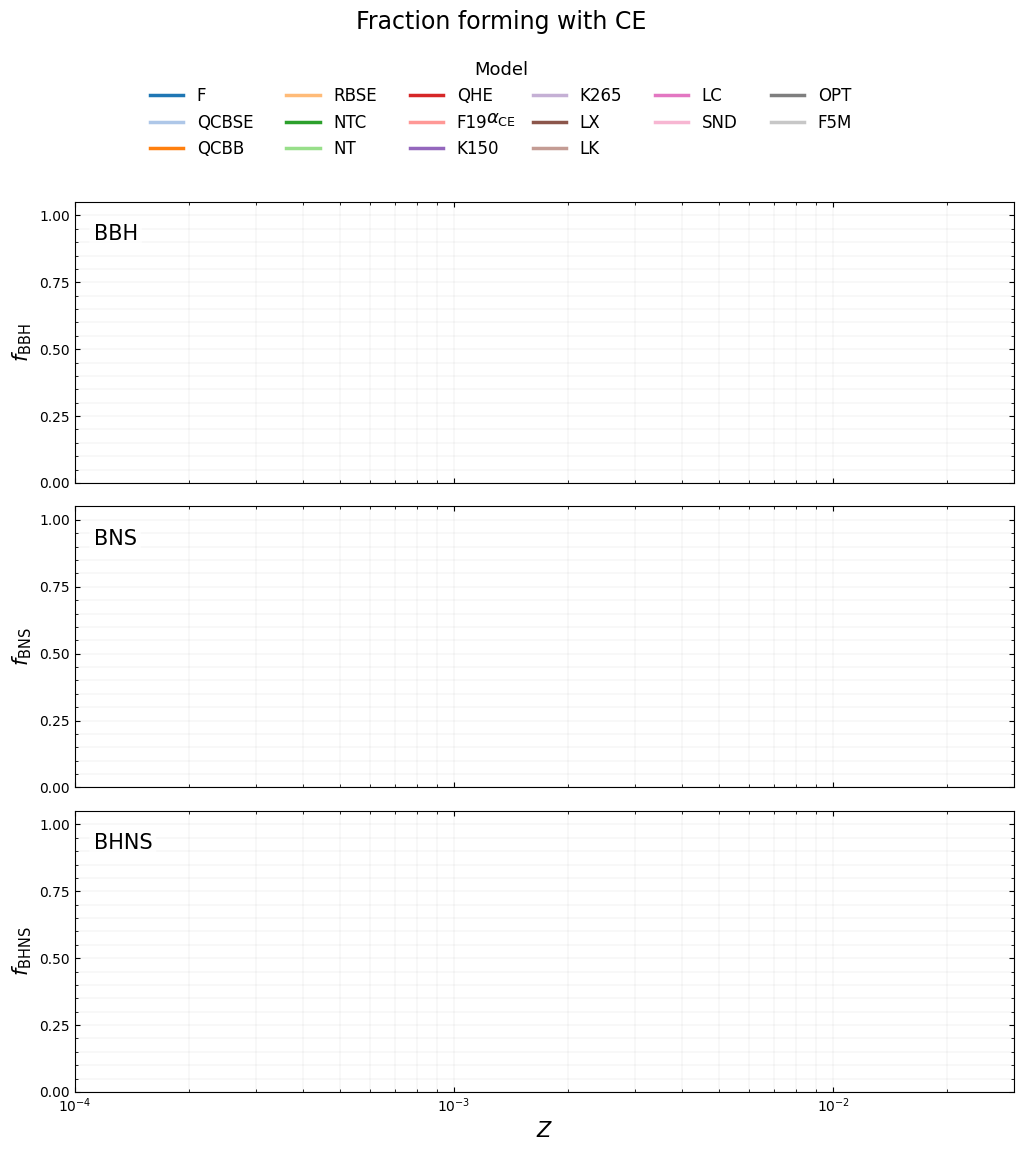

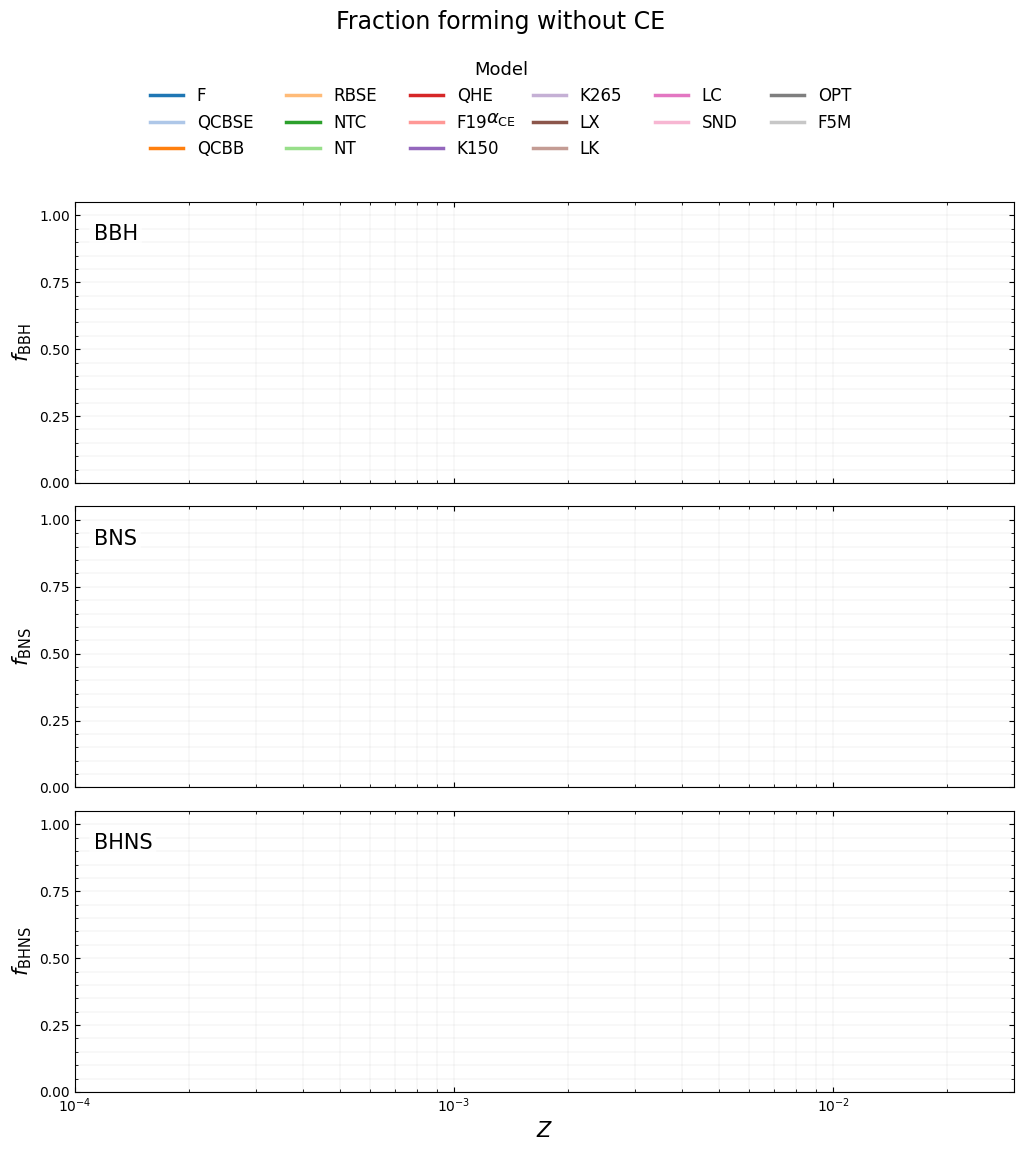

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D


LABELMAP = {
    "BHBH": "BBH",
    "BHBHm": "BBH",
    "NSNS": "BNS",
    "NSNSm": "BNS",
    "BHNS": "BHNS",
    "BHNSm": "BHNS",
}

LABEL_SIZE = 15


def compute_collapsed_fractions(
    df,
    alpha,
    bco_type,
    min_with_ce_count_bns=1,
    min_total_count_bns=1,
    mask_zero_bns=True,
):
    """
    Return:
      with_CE    = CI + CIII + CIV
      without_CE = CII
      others     = 1 - (with_CE + without_CE)

    as a function of Z for a given alpha and compact-object type.

    For BNS only, optionally mask points where the absolute number of
    systems contributing to the with-CE channel is too small.
    """
    sub = df[df["alpha"] == alpha].sort_values("Z")
    if sub.empty:
        return None

    z = sub["Z"].to_numpy(dtype=float)
    tot = sub[bco_type].to_numpy(dtype=float)
    ci = sub[f"{bco_type}I"].to_numpy(dtype=float)
    cii = sub[f"{bco_type}II"].to_numpy(dtype=float)
    ciii = sub[f"{bco_type}III"].to_numpy(dtype=float)
    civ = sub[f"{bco_type}IV"].to_numpy(dtype=float)

    with_ce_count = ci + ciii + civ

    with np.errstate(divide="ignore", invalid="ignore"):
        f_i = np.divide(ci, tot, out=np.full_like(ci, np.nan), where=tot > 0)
        f_ii = np.divide(cii, tot, out=np.full_like(cii, np.nan), where=tot > 0)
        f_iii = np.divide(ciii, tot, out=np.full_like(ciii, np.nan), where=tot > 0)
        f_iv = np.divide(civ, tot, out=np.full_like(civ, np.nan), where=tot > 0)

    f_with_ce = f_i + f_iii + f_iv
    f_without_ce = f_ii
    f_others = 1.0 - (f_with_ce + f_without_ce)

    # ---------------------------------------------------------
    # Mask unreliable BNS with-CE fractions
    # ---------------------------------------------------------
    if bco_type in {"NSNS", "NSNSm"}:
        bad = np.zeros_like(z, dtype=bool)

        if min_with_ce_count_bns is not None:
            bad |= (with_ce_count < min_with_ce_count_bns)

        if min_total_count_bns is not None:
            bad |= (tot < min_total_count_bns)

        if mask_zero_bns:
            bad |= (with_ce_count <= 0)

        # Only mask the with-CE curve
        f_with_ce = f_with_ce.astype(float)
        f_with_ce[bad] = np.nan

    return {
        "Z": z,
        "with_CE": f_with_ce,
        "without_CE": f_without_ce,
        "others": f_others,
    }


def format_axis(ax, row_idx, nrows, ylabel):
    ax.set_xscale("log")
    ax.set_xlim(1e-4, 0.03)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.grid(which="both", lw=0.25, alpha=0.5)
    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)

    ax.set_ylabel(ylabel, fontsize=LABEL_SIZE)

    if row_idx == nrows - 1:
        ax.set_xlabel("$Z$", fontsize=LABEL_SIZE)
    else:
        ax.tick_params(labelbottom=False)


def make_overlay_figure(
    model_dic,
    my_loc=None,
    merging=True,
    which_fraction="with_CE",
    figsize=(11, 12),
    save=True,
    output_name=None,
):
    """
    Create one big figure with 3 rows:
      BBH
      BNS
      BHNS

    All models and all alphas are overlaid in each panel.

    Parameters
    ----------
    which_fraction : str
        "with_CE" or "without_CE"
    """
    if which_fraction not in {"with_CE", "without_CE"}:
        raise ValueError("which_fraction must be 'with_CE' or 'without_CE'")

    bco_types = ("BHBHm", "NSNSm", "BHNSm") if merging else ("BHBH", "NSNS", "BHNS")

    # collect all alpha values across all models
    all_alphas = set()
    for model, path in model_dic.items():
        summary_file = os.path.join(path, "summary.csv")
        if os.path.exists(summary_file):
            df = pd.read_csv(summary_file)
            all_alphas.update(df["alpha"].dropna().unique())

    all_alphas = sorted(all_alphas)

    # styles:
    #   color = model
    #   linestyle = alpha
    cmap = plt.get_cmap("tab20")
    model_names = list(model_dic.keys())
    model_colors = {model: cmap(i % 20) for i, model in enumerate(model_names)}

    linestyle_cycle = ["-", "--", "-.", ":"]
    alpha_linestyles = {
        alpha: linestyle_cycle[i % len(linestyle_cycle)]
        for i, alpha in enumerate(all_alphas)
    }

    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=figsize,
        sharex=True,
        sharey=True,
    )

    axes = np.atleast_1d(axes)

    for row_idx, bco_type in enumerate(bco_types):
        ax = axes[row_idx]

        for model, path in model_dic.items():
            summary_file = os.path.join(path, "summary.csv")
            if not os.path.exists(summary_file):
                print(f"Warning: missing file {summary_file}")
                continue

            df = pd.read_csv(summary_file)
            alphas = sorted(df["alpha"].dropna().unique())

            for alpha in alphas:
                result = compute_collapsed_fractions(df, alpha, bco_type)
                if result is None:
                    continue

                ax.plot(
                    result["Z"],
                    result[which_fraction],
                    color=model_colors[model],
                    linestyle=alpha_linestyles[alpha],
                    lw=2.0,
                    alpha=0.95,
                )

        ylabel = f"$f_\\mathrm{{{LABELMAP[bco_type]}}}$"
        format_axis(ax, row_idx, len(bco_types), ylabel)

        panel_title = LABELMAP[bco_type]
        ax.text(
            0.02, 0.92, panel_title,
            transform=ax.transAxes,
            fontsize=LABEL_SIZE,
            va="top",
            ha="left",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
        )

    if which_fraction == "with_CE":
        fig.suptitle("Fraction forming with CE", fontsize=LABEL_SIZE + 2, y=0.995)
    else:
        fig.suptitle("Fraction forming without CE", fontsize=LABEL_SIZE + 2, y=0.995)

    # legends
    model_handles = [
        Line2D([0], [0], color=model_colors[model], lw=2.5, label=model)
        for model in model_names
    ]
    alpha_handles = [
        Line2D([0], [0], color="black", lw=2.5, linestyle=alpha_linestyles[alpha], label=rf"$\alpha_{{CE}}={alpha}$")
        for alpha in all_alphas
    ]

    fig.legend(
        handles=model_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.965),
        ncol=min(6, max(1, len(model_handles))),
        frameon=False,
        fontsize=LABEL_SIZE - 3,
        title="Model",
        title_fontsize=LABEL_SIZE - 2,
    )

    fig.legend(
        handles=alpha_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.925),
        ncol=min(4, max(1, len(alpha_handles))),
        frameon=False,
        fontsize=LABEL_SIZE - 3,
        title=r"$\alpha_{\mathrm{CE}}$",
        title_fontsize=LABEL_SIZE - 2,
    )

    fig.tight_layout(rect=[0.04, 0.04, 0.98, 0.88])

    if save:
        if output_name is None:
            output_name = f"overlay_{which_fraction}.pdf"
        fig.savefig(output_name, bbox_inches="tight")

    return fig, axes


# -------------------------------------------------------------------
# paths
# -------------------------------------------------------------------

my_loc = "/Users/floorbroekgaarden/Projects/GitHub/iorio22_plot-v3-formation_channels/data_from_simulations/"

model_dic = {
    "F": os.path.join(my_loc, "simulation_F"),
    "QCBSE": os.path.join(my_loc, "simulation_QCBSE"),
    "QCBB": os.path.join(my_loc, "simulation_QCBB"),
    "RBSE": os.path.join(my_loc, "simulation_RBSE"),
    "NTC": os.path.join(my_loc, "simulation_NTC"),
    "NT": os.path.join(my_loc, "simulation_NT"),
    "QHE": os.path.join(my_loc, "simulation_QHE"),
    "F19": os.path.join(my_loc, "simulation_F19"),
    "K150": os.path.join(my_loc, "simulation_K150"),
    "K265": os.path.join(my_loc, "simulation_K265"),
    "LX": os.path.join(my_loc, "simulation_LX"),
    "LK": os.path.join(my_loc, "simulation_LK"),
    "LC": os.path.join(my_loc, "simulation_LC"),
    "SND": os.path.join(my_loc, "simulation_SND"),
    "OPT": os.path.join(my_loc, "simulation_OPT"),
    "F5M": os.path.join(my_loc, "simulation_F5M"),
}

# -------------------------------------------------------------------
# make the two figures
# -------------------------------------------------------------------

fig1, axes1 = make_overlay_figure(
    model_dic=model_dic,
    merging=True,
    which_fraction="with_CE",
    figsize=(11, 12),
    save=True,
    output_name="all_models_with_CE.pdf",
)

fig2, axes2 = make_overlay_figure(
    model_dic=model_dic,
    merging=True,
    which_fraction="without_CE",
    figsize=(11, 12),
    save=True,
    output_name="all_models_without_CE.pdf",
)

plt.show()

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator


CHANNEL_COLORS = {
    "with_CE": "blueviolet",
    "without_CE": "palevioletred",
    "Others": "gray",
}

LABELMAP = {
    "BHBH": "BBH",
    "BHBHm": "BBHm",
    "NSNS": "BNS",
    "NSNSm": "BNSm",
    "BHNS": "BHNS",
    "BHNSm": "BHNSm",
}

LABEL_SIZE = 16


def compute_channel_fractions(df, alphas, bco_type):
    """
    Sum over one or more alpha values, then return:
      - with_CE     = CI + CIII + CIV
      - without_CE  = CII
      - others      = 1 - (with_CE + without_CE)
    as a function of Z.
    """
    alphas = np.atleast_1d(alphas)

    x = None
    n_tot = None
    ch_i = None
    ch_ii = None
    ch_iii = None
    ch_iv = None

    for alpha in alphas:
        sub = df[df["alpha"] == alpha].sort_values("Z")
        if sub.empty:
            continue

        z = sub["Z"].to_numpy(dtype=float)
        tot = sub[bco_type].to_numpy(dtype=float)
        ci = sub[f"{bco_type}I"].to_numpy(dtype=float)
        cii = sub[f"{bco_type}II"].to_numpy(dtype=float)
        ciii = sub[f"{bco_type}III"].to_numpy(dtype=float)
        civ = sub[f"{bco_type}IV"].to_numpy(dtype=float)

        if x is None:
            x = z
            n_tot = tot
            ch_i = ci
            ch_ii = cii
            ch_iii = ciii
            ch_iv = civ
        else:
            n_tot += tot
            ch_i += ci
            ch_ii += cii
            ch_iii += ciii
            ch_iv += civ

    if x is None:
        raise ValueError(f"No data found for alphas={alphas} and bco_type={bco_type}")

    with np.errstate(divide="ignore", invalid="ignore"):
        f_i = np.divide(ch_i, n_tot, out=np.zeros_like(ch_i), where=n_tot > 0)
        f_ii = np.divide(ch_ii, n_tot, out=np.zeros_like(ch_ii), where=n_tot > 0)
        f_iii = np.divide(ch_iii, n_tot, out=np.zeros_like(ch_iii), where=n_tot > 0)
        f_iv = np.divide(ch_iv, n_tot, out=np.zeros_like(ch_iv), where=n_tot > 0)

    f_with_ce = f_i + f_iii + f_iv
    f_without_ce = f_ii
    f_others = 1.0 - (f_with_ce + f_without_ce)

    return x, f_with_ce, f_without_ce, f_others


def plot_aoe(ax, df, alphas, bco_type, label=True):
    """
    Plot absolute fractions for:
      - with CE
      - without CE
      - Others
    """
    x, f_with_ce, f_without_ce, f_others = compute_channel_fractions(df, alphas, bco_type)

    ax.plot(
        x, f_with_ce,
        lw=2.5,
        color=CHANNEL_COLORS["with_CE"],
        marker="o",
        ms=4,
        label="with CE" if label else None,
    )
    ax.plot(
        x, f_without_ce,
        lw=2.5,
        color=CHANNEL_COLORS["without_CE"],
        marker="s",
        ms=4,
        label="without CE" if label else None,
    )
    ax.plot(
        x, f_others,
        lw=2.0,
        color=CHANNEL_COLORS["Others"],
        ls=":",
        marker="D",
        ms=3.5,
        label="Others" if label else None,
    )


def format_panel(ax, row_idx, col_idx, alpha, bco_type):
    ax.set_xscale("log")
    ax.set_xlim(1e-4, 0.03)
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.grid(which="both", lw=0.2)

    if col_idx == 0:
        ax.set_ylabel(f"$f_\\mathrm{{{LABELMAP[bco_type]}}}$", fontsize=LABEL_SIZE)
        ax.tick_params(
            axis="y",
            which="both",
            right=True,
            direction="in",
            top=True,
            left=True,
            labelright=False,
            labelleft=True,
        )
    else:
        ax.tick_params(
            axis="y",
            which="both",
            right=True,
            direction="in",
            top=True,
            left=True,
            labelright=False,
            labelleft=False,
        )

    if row_idx == 2:
        ax.set_xlabel("$Z$", fontsize=LABEL_SIZE)
        ax.tick_params(
            axis="x",
            which="both",
            right=True,
            direction="in",
            top=True,
            labeltop=False,
            labelbottom=True,
        )
    else:
        ax.tick_params(
            axis="x",
            which="both",
            right=True,
            direction="in",
            top=True,
            labeltop=False,
            labelbottom=False,
        )

    if row_idx == 0:
        ax.set_title(f"$\\alpha_\\mathrm{{CE}}={alpha}$", fontsize=LABEL_SIZE)


def multiplot_channel_aoe(path, model, merging=True, legend_on=(0, 0), save=True):
    summary_file = os.path.join(path, "summary.csv")
    df = pd.read_csv(summary_file)

    bco_types = ("BHBHm", "NSNSm", "BHNSm") if merging else ("BHBH", "NSNS", "BHNS")
    alphas = np.sort(df["alpha"].unique())

    fig, axes = plt.subplots(
        nrows=len(bco_types),
        ncols=len(alphas),
        figsize=(15, 10),
        sharex=False,
        sharey=False,
    )

    axes = np.atleast_2d(axes)

    for row_idx, bco_type in enumerate(bco_types):
        for col_idx, alpha in enumerate(alphas):
            ax = axes[row_idx, col_idx]
            plot_aoe(
                ax,
                df,
                alpha,
                bco_type,
                label=(row_idx == 0 and col_idx == 0),
            )
            format_panel(ax, row_idx, col_idx, alpha, bco_type)

    leg_row, leg_col = legend_on
    axes[leg_row, leg_col].legend(ncol=1, fontsize=LABEL_SIZE - 4, frameon=False)

    fig.tight_layout()

    if save:
        fig.savefig(f"plot_channel_aoe_{model}.pdf", bbox_inches="tight")

    return fig, axes


my_loc = "/Users/floorbroekgaarden/Projects/GitHub/iorio22_plot-v3-formation_channels/data_from_simulations/"

model_dic = {
    "F": os.path.join(my_loc, "simulation_F"),
    "QCBSE": os.path.join(my_loc, "simulation_QCBSE"),
    "QCBB": os.path.join(my_loc, "simulation_QCBB"),
    "RBSE": os.path.join(my_loc, "simulation_RBSE"),
    "NTC": os.path.join(my_loc, "simulation_NTC"),
    "NT": os.path.join(my_loc, "simulation_NT"),
    "QHE": os.path.join(my_loc, "simulation_QHE"),
    "F19": os.path.join(my_loc, "simulation_F19"),
    "K150": os.path.join(my_loc, "simulation_K150"),
    "K265": os.path.join(my_loc, "simulation_K265"),
    "LX": os.path.join(my_loc, "simulation_LX"),
    "LK": os.path.join(my_loc, "simulation_LK"),
    "LC": os.path.join(my_loc, "simulation_LC"),
    "SND": os.path.join(my_loc, "simulation_SND"),
    "OPT": os.path.join(my_loc, "simulation_OPT"),
    "F5M": os.path.join(my_loc, "simulation_F5M"),
}

for model, path in model_dic.items():
    fig, axes = multiplot_channel_aoe(path, model)
    plt.show(fig)
    plt.close(fig)
    
    

FileNotFoundError: [Errno 2] No such file or directory: '/Users/floorbroekgaarden/Projects/GitHub/iorio22_plot-v3-formation_channels/data_from_simulations/simulation_F/summary.csv'

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import numpy as np
# from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
#                                AutoMinorLocator,LogLocator)

# import matplotlib as mpl
# label_size =18
# mpl.rcParams['xtick.labelsize'] = label_size
# mpl.rcParams['ytick.labelsize'] = label_size
# #mpl.rcParams['mathtext.default']='regular'
# mpl.rcParams.update({'figure.autolayout': True})
# mpl.rcParams['contour.negative_linestyle'] = 'solid'
# mpl.rcParams['axes.facecolor'] = 'white'
# mpl.rcParams['xtick.major.size'] = 10
# mpl.rcParams['xtick.major.width'] = 1.5
# mpl.rcParams['xtick.minor.size'] = 5
# mpl.rcParams['xtick.minor.width'] = 1
# mpl.rcParams['ytick.major.size'] = 10
# mpl.rcParams['ytick.major.width'] = 1.5
# mpl.rcParams['ytick.minor.size'] = 5
# mpl.rcParams['ytick.minor.width'] = 1
# import warnings
# warnings.filterwarnings('ignore')
# import subprocess
# import warnings
# warnings.filterwarnings('ignore')
# import subprocess

# import matplotlib.colors as colors

# import sys

# import os
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.ticker import MultipleLocator


# CHANNEL_COLORS = {
#     "CI": "blueviolet",
#     "CII": "palevioletred",
#     "CIII": "sandybrown",
#     "CIV": "darkblue",
#     "Others": "gray",
#     "CK": "black",
# }

# LABELMAP = {
#     "BHBH": "BBH",
#     "BHBHm": "BBHm",
#     "NSNS": "BNS",
#     "NSNSm": "BNSm",
#     "BHNS": "BHNS",
#     "BHNSm": "BHNSm",
# }

# LABEL_SIZE = 16


# def compute_channel_fractions(df, alphas, bco_type):
#     """
#     Sum over one or more alpha values, then return the absolute
#     fraction in each formation channel as a function of Z.
#     """
#     alphas = np.atleast_1d(alphas)

#     x = None
#     n_tot = None
#     ch_i = None
#     ch_ii = None
#     ch_iii = None
#     ch_iv = None
#     n_k = None

#     for alpha in alphas:
#         sub = df[df["alpha"] == alpha].sort_values("Z")
#         if sub.empty:
#             continue

#         z = sub["Z"].to_numpy(dtype=float)
#         tot = sub[bco_type].to_numpy(dtype=float)
#         ci = sub[f"{bco_type}I"].to_numpy(dtype=float)
#         cii = sub[f"{bco_type}II"].to_numpy(dtype=float)
#         ciii = sub[f"{bco_type}III"].to_numpy(dtype=float)
#         civ = sub[f"{bco_type}IV"].to_numpy(dtype=float)
#         ck = (
#             sub[f"{bco_type}K1"].to_numpy(dtype=float)
#             + sub[f"{bco_type}K2"].to_numpy(dtype=float)
#             + sub[f"{bco_type}K3"].to_numpy(dtype=float)
#         )

#         if x is None:
#             x = z
#             n_tot = tot
#             ch_i = ci
#             ch_ii = cii
#             ch_iii = ciii
#             ch_iv = civ
#             n_k = ck
#         else:
#             n_tot += tot
#             ch_i += ci
#             ch_ii += cii
#             ch_iii += ciii
#             ch_iv += civ
#             n_k += ck

#     if x is None:
#         raise ValueError(f"No data found for alphas={alphas} and bco_type={bco_type}")

#     with np.errstate(divide="ignore", invalid="ignore"):
#         f_i = np.divide(ch_i, n_tot, out=np.zeros_like(ch_i), where=n_tot > 0)
#         f_ii = np.divide(ch_ii, n_tot, out=np.zeros_like(ch_ii), where=n_tot > 0)
#         f_iii = np.divide(ch_iii, n_tot, out=np.zeros_like(ch_iii), where=n_tot > 0)
#         f_iv = np.divide(ch_iv, n_tot, out=np.zeros_like(ch_iv), where=n_tot > 0)
#         f_k = np.divide(n_k, n_tot, out=np.zeros_like(n_k), where=n_tot > 0)

#     f_other = 1.0 - (f_i + f_ii + f_iii + f_iv)

#     return x, f_i, f_ii, f_iii, f_iv, f_other, f_k


# def plot_aoe(ax, df, alphas, bco_type, collisions=False, label=True):
#     """
#     Plot absolute channel fractions (not stacked).
#     """
#     x, f_i, f_ii, f_iii, f_iv, f_other, f_k = compute_channel_fractions(df, alphas, bco_type)

#     ax.plot(
#         x, f_i, lw=2.5, color=CHANNEL_COLORS["CI"],
#         label="CI" if label else None
#     )
#     ax.plot(
#         x, f_ii, lw=2.5, color=CHANNEL_COLORS["CII"],
#         label="CII" if label else None
#     )
#     ax.plot(
#         x, f_iii, lw=2.5, color=CHANNEL_COLORS["CIII"],
#         label="CIII" if label else None
#     )
#     ax.plot(
#         x, f_iv, lw=2.5, color=CHANNEL_COLORS["CIV"],
#         label="CIV" if label else None
#     )
#     ax.plot(
#         x, f_other, lw=2.0, color=CHANNEL_COLORS["Others"], ls=":",
#         label="Others" if label else None
#     )

#     if collisions:
#         ax.plot(
#             x, f_k, lw=2.5, color=CHANNEL_COLORS["CK"], ls="--",
#             label="CK" if label else None
#         )


# def format_panel(ax, row_idx, col_idx, alpha, bco_type):
#     ax.set_xscale("log")
#     ax.set_xlim(1e-4, 0.03)
#     ax.set_ylim(0, 1.0)
#     ax.yaxis.set_minor_locator(MultipleLocator(0.05))
#     ax.yaxis.set_major_locator(MultipleLocator(0.25))
#     ax.grid(which="both", lw=0.2)

#     if col_idx == 0:
#         ax.set_ylabel(f"$f_\\mathrm{{{LABELMAP[bco_type]}}}$", fontsize=LABEL_SIZE)
#         ax.tick_params(
#             axis="y", which="both",
#             right=True, direction="in", top=True, left=True,
#             labelright=False, labelleft=True
#         )
#     else:
#         ax.tick_params(
#             axis="y", which="both",
#             right=True, direction="in", top=True, left=True,
#             labelright=False, labelleft=False
#         )

#     if row_idx == 2:
#         ax.set_xlabel("$Z$", fontsize=LABEL_SIZE)
#         ax.tick_params(
#             axis="x", which="both",
#             right=True, direction="in", top=True,
#             labeltop=False, labelbottom=True
#         )
#     else:
#         ax.tick_params(
#             axis="x", which="both",
#             right=True, direction="in", top=True,
#             labeltop=False, labelbottom=False
#         )

#     if row_idx == 0:
#         ax.set_title(f"$\\alpha_\\mathrm{{CE}}={alpha}$", fontsize=LABEL_SIZE)


# def multiplot_channel_aoe(path, model, merging=True, legend_on=(0, 0), save=True):
#     summary_file = os.path.join(path, "summary.csv")
#     df = pd.read_csv(summary_file)

#     bco_types = ("BHBHm", "NSNSm", "BHNSm") if merging else ("BHBH", "NSNS", "BHNS")
#     alphas = np.sort(df["alpha"].unique())

#     fig, axes = plt.subplots(
#         nrows=len(bco_types),
#         ncols=len(alphas),
#         figsize=(15, 10),
#         sharex=False,
#         sharey=False
#     )

#     axes = np.atleast_2d(axes)

#     for row_idx, bco_type in enumerate(bco_types):
#         for col_idx, alpha in enumerate(alphas):
#             ax = axes[row_idx, col_idx]
#             plot_aoe(
#                 ax,
#                 df,
#                 alpha,
#                 bco_type,
#                 collisions=True,
#                 label=(row_idx == 0 and col_idx == 0)
#             )
#             format_panel(ax, row_idx, col_idx, alpha, bco_type)

#     leg_row, leg_col = legend_on
#     axes[leg_row, leg_col].legend(ncol=2, fontsize=LABEL_SIZE - 6, frameon=False)

#     fig.tight_layout()

#     if save:
#         fig.savefig(f"plot_channel_aoe_{model}.pdf", bbox_inches="tight")

#     return fig, axes


# my_loc = "/Users/floorbroekgaarden/Projects/GitHub/iorio22_plot-v3-formation_channels/data_from_simulations/"

# model_dic = {
#     "F": os.path.join(my_loc, "simulation_F"),
#     "QCBSE": os.path.join(my_loc, "simulation_QCBSE"),
#     "QCBB": os.path.join(my_loc, "simulation_QCBB"),
#     "RBSE": os.path.join(my_loc, "simulation_RBSE"),
#     "NTC": os.path.join(my_loc, "simulation_NTC"),
#     "NT": os.path.join(my_loc, "simulation_NT"),
#     "QHE": os.path.join(my_loc, "simulation_QHE"),
#     "F19": os.path.join(my_loc, "simulation_F19"),
#     "K150": os.path.join(my_loc, "simulation_K150"),
#     "K265": os.path.join(my_loc, "simulation_K265"),
#     "LX": os.path.join(my_loc, "simulation_LX"),
#     "LK": os.path.join(my_loc, "simulation_LK"),
#     "LC": os.path.join(my_loc, "simulation_LC"),
#     "SND": os.path.join(my_loc, "simulation_SND"),
#     "OPT": os.path.join(my_loc, "simulation_OPT"),
#     "F5M": os.path.join(my_loc, "simulation_F5M"),
# }

# for model, path in model_dic.items():
#     fig, axes = multiplot_channel_aoe(path, model)
#     plt.show(fig)
#     plt.close(fig)

In [ ]:
# data lives here  
# 

### Broekgaarden 

In [ ]:
# # with the saved calculated yields per formation channel and metallicity in the location: /Users/floorbroekgaarden/Projects/GitHub/DCO_FormationChannels/dataFiles/data_Fig_1/formation_channels_per_Z_hdf5weights_DCOname.csv
    
# #



# def plotGridFormationRatePerMetallicity_grouped(
#     DCOtype='BBH',
#     Ylim=10,
#     csvPath=None,
#     plot_stacked=True,
#     plot_fraction=False,
#     include_vii_in_with_CE=False,
# ):
#     dictDCOtypeDCOlabel = {'BBH': 'BHBH', 'BNS': 'NSNS', 'BHNS': 'BHNS', 'NSBH': 'NSBH'}
#     DCOname = dictDCOtypeDCOlabel[DCOtype]

#     print('doing DCO type', DCOtype)

#     csv_file = os.path.join(csvPath, f'formation_channels_per_Z_hdf5weights_{DCOname}.csv')
#     log10metallicities = np.log10(np.asarray(metallicities_list))
#     BPSnameslist = list(string.ascii_uppercase)[0:nModels]

#     ncols, nrows = 3, 7
#     f, axe = plt.subplots(
#         ncols=ncols,
#         nrows=nrows,
#         figsize=(22, 26),
#         gridspec_kw={"width_ratios": 1*np.ones(ncols), "height_ratios": 1*np.ones(nrows)}
#     )

#     grouped_labels = ['with CE', 'without CE', 'other']
#     grouped_colors = ['tab:red', 'tab:blue', 'gray']

#     for ind_m, bps_model in enumerate(BPSnameslist):
#         ii, jj = int(ind_m / ncols) % nrows, ind_m % ncols

#         grouped = load_grouped_formation_channels(
#             csv_file=csv_file,
#             bps_model=bps_model,
#             headerDict_Z_rev=headerDict_Z_rev,
#             include_vii_in_with_CE=include_vii_in_with_CE,
#         )

#         grouped_rates = [
#             grouped['with_CE'],
#             grouped['without_CE'],
#             grouped['other'],
#         ]

#         axe[ii, jj] = plotFormationChannelsGroupedSingle(
#             axe=axe[ii, jj],
#             metallicities=log10metallicities,
#             grouped_rates=grouped_rates,
#             colorlist=grouped_colors,
#             labels=grouped_labels,
#             BPSmodelname=bps_model,
#             Ylim=Ylim,
#             DCOtype=DCOtype,
#             plot_stacked=plot_stacked,
#             plot_fraction=plot_fraction,
#         )

#     fs_label = 20
#     ylabel = r'$\eta \ \  [10^{-5}\ \rm{M}_{\odot}^{-1}]\  $'
#     xlabel = r'$\log_{10}(Z_{\rm{i}})$'
#     if plot_fraction:
#         ylabel = r'$\textbf{fraction}$'

#     for ii in range(nrows-1):
#         axe[ii,0] = layoutAxesNoXlabel(axe[ii,0], nameX=None, nameY=ylabel, fontsize=fs_label)
#     axe[nrows-1,0] = layoutAxes(axe[nrows-1,0], nameX=xlabel, nameY=ylabel, fontsize=fs_label)

#     for ii in range(nrows-1):
#         axe[ii,1] = layoutAxesNoXandYlabel(axe[ii,1], nameX=None, nameY=None, fontsize=fs_label)
#     axe[nrows-1,1] = layoutAxesNoYlabel(axe[nrows-1,1], nameX=xlabel, nameY='xx', fontsize=fs_label)

#     for ii in range(nrows-2):
#         axe[ii,2] = layoutAxesNoXandYlabel(axe[ii,2], nameX=None, nameY=None, fontsize=fs_label)

#     axe[nrows-2,2] = layoutAxesNoYlabel(axe[nrows-2,2], nameX=xlabel, nameY=None, fontsize=fs_label)
#     axe[nrows-1,2].axis('off')
#     axe[nrows-2,2].set_zorder(100)

#     for ii in range(nrows-2):
#         axe[ii,2].tick_params(labelbottom=False, labelleft=False)
#     for ii in range(nrows-1):
#         axe[ii,1].tick_params(labelbottom=False, labelleft=False)
#     for ii in range(nrows-1):
#         axe[ii,0].tick_params(labelbottom=False)

#     axe[nrows-1,1].tick_params(labelleft=False)
#     axe[nrows-2,2].tick_params(labelleft=False)

#     plt.tight_layout()
#     plt.subplots_adjust(wspace=0.05, hspace=0.05)

#     stack_str = 'stacked' if plot_stacked else 'notstacked'
#     fract_str = '_fraction' if plot_fraction else '_yield'

#     plt.savefig(f'./FormationRatePerZ_{DCOname}_grouped_{stack_str}{fract_str}.pdf')
#     plt.show()
#     plt.close()

    
# def plotFormationChannelsPerMetallicitySingle(axe=[], metallicities=[0.001, 0.33], formationRates=[0,0], colorlist=['k'], totalcolor='k', BPSmodelname='A',Ylim=3.85, DCOtype='BBH', plot_stacked=True, plot_fraction=False):
#     """
    
#     plots a single panel with formation channel yields per metallicity
    
#     """
    
#     # start building from 0
#     upperY = np.zeros_like(formationRates[0])
#     lowerY = np.zeros_like(formationRates[0])
    
#     # go over rates of channels
#     total = 0 
#     for ind_c, c_rate in enumerate(formationRates):
#         total += c_rate 
    
#     total_sum = np.sum(total)
    
    
#     plotfactor_higher=False
#     if plot_fraction==False:
#         if (DCOtype=='BNS') & (BPSmodelname in [ "E", "H"]):
#             plotfactor_higher=10
#         # multiply the rate by a factor 10 (or chosen factor) to make the yields visible in the large figure
#         elif (DCOtype=='BHNS') & (BPSmodelname in [ "E", "G"]):
#             plotfactor_higher=10        
    
    
#     for ind_c, c_rate in enumerate(formationRates[:]):
        
        
#         if plot_fraction==True:
#             fc_plot_rate = c_rate/total # take the fraction
# #                 print('between 0 1 ', c_rate)
#         else:
#             fc_plot_rate = c_rate*1e5
        
#         # add this rate, 
#         if plotfactor_higher==False:
#             upperY += fc_plot_rate
#         else:
#             upperY+= fc_plot_rate*plotfactor_higher
            
        
        
#         percentage = (np.sum(c_rate) / total_sum)*100.
#         percentage_str =  r'$%s$'%str((roundAndFormat1(percentage))) + str(r'\%')
        
        
#         if plot_stacked==True:
#         # 1e5 to make the numbers nice
# #             print('ind_c ', ind_c)
# #             print('lowerY, ', lowerY)
# #             print('upperY', upperY.values)
#             axe.fill_between(metallicities, lowerY, upperY, facecolor=colorlist[ind_c], \
#                       lw=3, alpha=1, label=percentage_str)
# #             axe.plot(metallicities, lowerY, lw=5, color='blue')
# #             axe.plot(metallicities, upperY, lw=5, color='red')
#         else:
            
#             if plotfactor_higher==False:
#                 axe.plot(metallicities, fc_plot_rate, color=colorlist[ind_c], \
#                           lw=3, alpha=1, label=percentage_str)  
#             else:
#                 axe.plot(metallicities, fc_plot_rate*plotfactor_higher, color=colorlist[ind_c], \
#                           lw=3, alpha=1, label=percentage_str)              
        
#         if plotfactor_higher==False:
#             lowerY += fc_plot_rate
#         else:
#             lowerY += fc_plot_rate*plotfactor_higher    
            
    
    
#     ### second axes ###
# #     if plot_fraction==True:
# #         ax2y = axe.twinx()
# #         ylabel2 =  r'$\eta \ \  [10^{-5}\ \rm{M}_{\odot}^{-1}]\  $'   
# #         ax2y.set_ylim(bottom=0,top=8)
# #         cdfcolor='k'
# #         ax2y.plot(metallicities, total*1E5, color=cdfcolor, lw=3, alpha=1, linestyle=':')

# #         ax2y.tick_params(labelsize=fs-4, colors=cdfcolor)
# #         ax2y.set_ylabel(ylabel2, fontsize=fs, color=cdfcolor) 
        

    
    
#     ######## AXES LABELS, LEGENDS, LIMS,  ###########
#     # plot extra vertical line to indicate metallicities   
#     for zz_ind, zz in enumerate(metallicity_vlines_values_list) :
#         axe.plot([zz,zz], [0,Ylim+1], \
#                          c='k',\
#                          lw=1.2, alpha=1, linestyle=':', zorder=100)   
#         axe.text(zz-0.06, Ylim-0.022, s=metallicity_vlines_text_list[zz_ind], fontsize=fs-8.5, rotation=90, verticalalignment='top')   

    
#     # location of the small legends is on the left, unless it does not fit:
#     if DCOtype=='BBH':
#         x_box, y_box = 0.63, .4
#     elif (DCOtype=='BNS') and (BPSmodelname=='G'):
#         x_box, y_box = 0.63, .4
#     else:
#         x_box, y_box = 0.01, .47
    
#     if plot_fraction==False:
#         axe.legend(fontsize=14,  ncol=2, \
#                    bbox_to_anchor=(x_box, y_box),loc="lower left", borderaxespad=0., frameon=False).set_zorder(10000)
   
#     axe.set_xlim(min(metallicities), max(metallicities))
#     axe.set_ylim(0,Ylim)
        
#     bbox_props = dict(boxstyle="round", fc="w", ec="0.5", alpha=0.95)
#     axe.annotate(r'\textbf{model %s:}'%(BPSmodelname) +'\n' + alphabetPhysicalNameDict[BPSmodelname], xy=(0.022, .95),\
#                  xycoords='axes fraction', fontsize = fs, weight = 'bold', ha='left', va="top",bbox=bbox_props,\
#                 zorder=1E10)

#     if plotfactor_higher!=False:
#         axe.annotate(r'\textbf{%s}'%(plotfactor_higher) +r'$\times$',  xy=(0.88, .15),\
#                      xycoords='axes fraction', fontsize = fs+5, weight = 'bold', ha='left', va="top", zorder=1E10)        

    
#     return axe
    
    
    

# def plotGridFormationRatePerMetallicity(
#     DCOtype='BBH',
#     Ylim=10,
#     csvPath=None,
#     plot_stacked=True,
#     plot_fraction=False
#     ):

#     channel_names = ['classic', 'stable B no CEE', 'vii', 'immediate CE', 'double-core CE', 'other']
#     colorlist = [channelColorDict[i] for i in channel_names]

#     dictDCOtypeDCOlabel = {'BBH':'BHBH', 'BNS':'NSNS', 'BHNS':'BHNS', 'NSBH':'NSBH'}
#     DCOname = dictDCOtypeDCOlabel[DCOtype]

#     print('doing DCO type ', DCOtype)

#     # 👉 build path from user input
#     csv_file = f"{csvPath}/formation_channels_per_Z_hdf5weights_{DCOname}.csv"

#     # 👉 read ONCE
#     df = pd.read_csv(csv_file, index_col=0)

#     BPSnameslist = list(string.ascii_uppercase)[0:nModels]
#     log10metallicities = np.log10(np.asarray(metallicities_list))

#     ncols, nrows = 3, 7
#     f, axe = plt.subplots(
#         ncols=ncols,
#         nrows=nrows,
#         figsize=(22,26),
#         gridspec_kw={"width_ratios":1*np.ones(ncols), "height_ratios":1*np.ones(nrows)}
#     )

#     for ind_m, bps_model in enumerate(BPSnameslist[:]):

#         ii, jj = int(ind_m/ncols) % nrows, ind_m % ncols

#         formationRates = []

#         for c_ in channel_names:
#             key_ = bps_model + ' ' + headerDict_Z_rev[c_] + '  [Msun^{-1}]'
#             formationRates.append(df[key_])

#         axe[ii, jj] = plotFormationChannelsPerMetallicitySingle(
#             axe=axe[ii, jj],
#             metallicities=log10metallicities,
#             formationRates=formationRates,
#             colorlist=colorlist,
#             BPSmodelname=bps_model,
#             Ylim=Ylim,
#             DCOtype=DCOtype,
#             plot_stacked=plot_stacked,
#             plot_fraction=plot_fraction
#         )                               
    
#     ######### SET LABELS AND AXIS TICKS #########
#     fs_label = 20  # fontsize for x and y labels 
#     ylabel = r'$\eta \ \  [10^{-5}\ \rm{M}_{\odot}^{-1}]\  $'   
#     xlabel = r'$\log_{10}(Z_{\rm{i}})$'
#     if plot_fraction == True: ylabel = r'$\textbf{fraction}  $'   # overwrite ylabel
        
    
#     #### set labels for all needed panels in column 1 ####
#     for ii in range(nrows-1):   # set only ylabels for left most panels (first column)
#         axe[ii,0] = layoutAxesNoXlabel(axe[ii,0], nameX=None, nameY=ylabel, fontsize=fs_label)
#     # bottom left panel needs both axes labels
#     axe[nrows-1,0] = layoutAxes(axe[nrows-1,0], nameX=xlabel, nameY=ylabel, fontsize=fs_label)

#     ## set labels for all needed panels in column 2  ####
#     for ii in range(nrows-1):   # set only ylabels for left most panels (first column)
#         axe[ii,1] = layoutAxesNoXandYlabel(axe[ii,1], nameX=None, nameY=None, fontsize=fs_label)
#     axe[nrows-1,1] = layoutAxesNoYlabel(axe[nrows-1,1], nameX=xlabel, nameY='xx', fontsize=fs_label)
        
#     ## set labels for all needed panels in column 3  ####
#     for ii in range(nrows-2):   # set only ylabels for left most panels (first column)
#         axe[ii,2] = layoutAxesNoXandYlabel(axe[ii,2], nameX=None, nameY=None, fontsize=fs_label)

#     axe[nrows-2,2] = layoutAxesNoYlabel(axe[nrows-2,2], nameX=xlabel, nameY=None, fontsize=fs_label) 
#     axe[nrows-1,2].axis('off') # do not show the axes for the last empty panel 
#     axe[nrows-2,2].set_zorder(100) # this makes the panel of model R go up in zorder, needed to show "-4" axes tick above other panels
    
#     # do not show the axes tick labels for subplots that are not at the edge
#     for ii in range(nrows-2):
#         axe[ii,2].tick_params(labelbottom=False, labelleft=False)
#     for ii in range(nrows-1):
#         axe[ii,1].tick_params(labelbottom=False, labelleft=False)
#     for ii in range(nrows-1):
#         axe[ii,0].tick_params(labelbottom=False)  
#     # extra to remove left tick labels only for the bottom plots 
#     axe[nrows-1,1].tick_params(labelleft=False) 
#     axe[nrows-2,2].tick_params(labelleft=False) 
#     ################################################
    
    
#     plt.tight_layout() 
#     plt.subplots_adjust(wspace=0.05, hspace=0.05)
#     if plot_stacked==True: stack_str = 'stacked'
#     else: stack_str = 'notstacked'
#     if plot_fraction==True: fract_str = '_fraction'
#     else: fract_str = '_yield'
        
# #     plt.savefig('./FormationRatePerZ_'+ DCOname +'_' + stack_str + fract_str + '.png', dpi=600, transparent=True)
# #     plt.savefig('./FormationRatePerZ_'+ DCOname +'_' + stack_str + fract_str + '.pdf')
#     plt.show()
#     plt.close()
    
    
    
# csvPath = '/Users/floorbroekgaarden/Projects/GitHub/Double-Compact-Object-Mergers/dataFiles/summary_data_Fig_1/'

# plotGridFormationRatePerMetallicity_grouped(
#     DCOtype='BBH',
#     Ylim=8.89,
#     csvPath=csvPath,
#     plot_stacked=False,
#     plot_fraction=True,
#     include_vii_in_with_CE=False,  # set True if vii should belong to CE
# )

doing DCO type  BBH


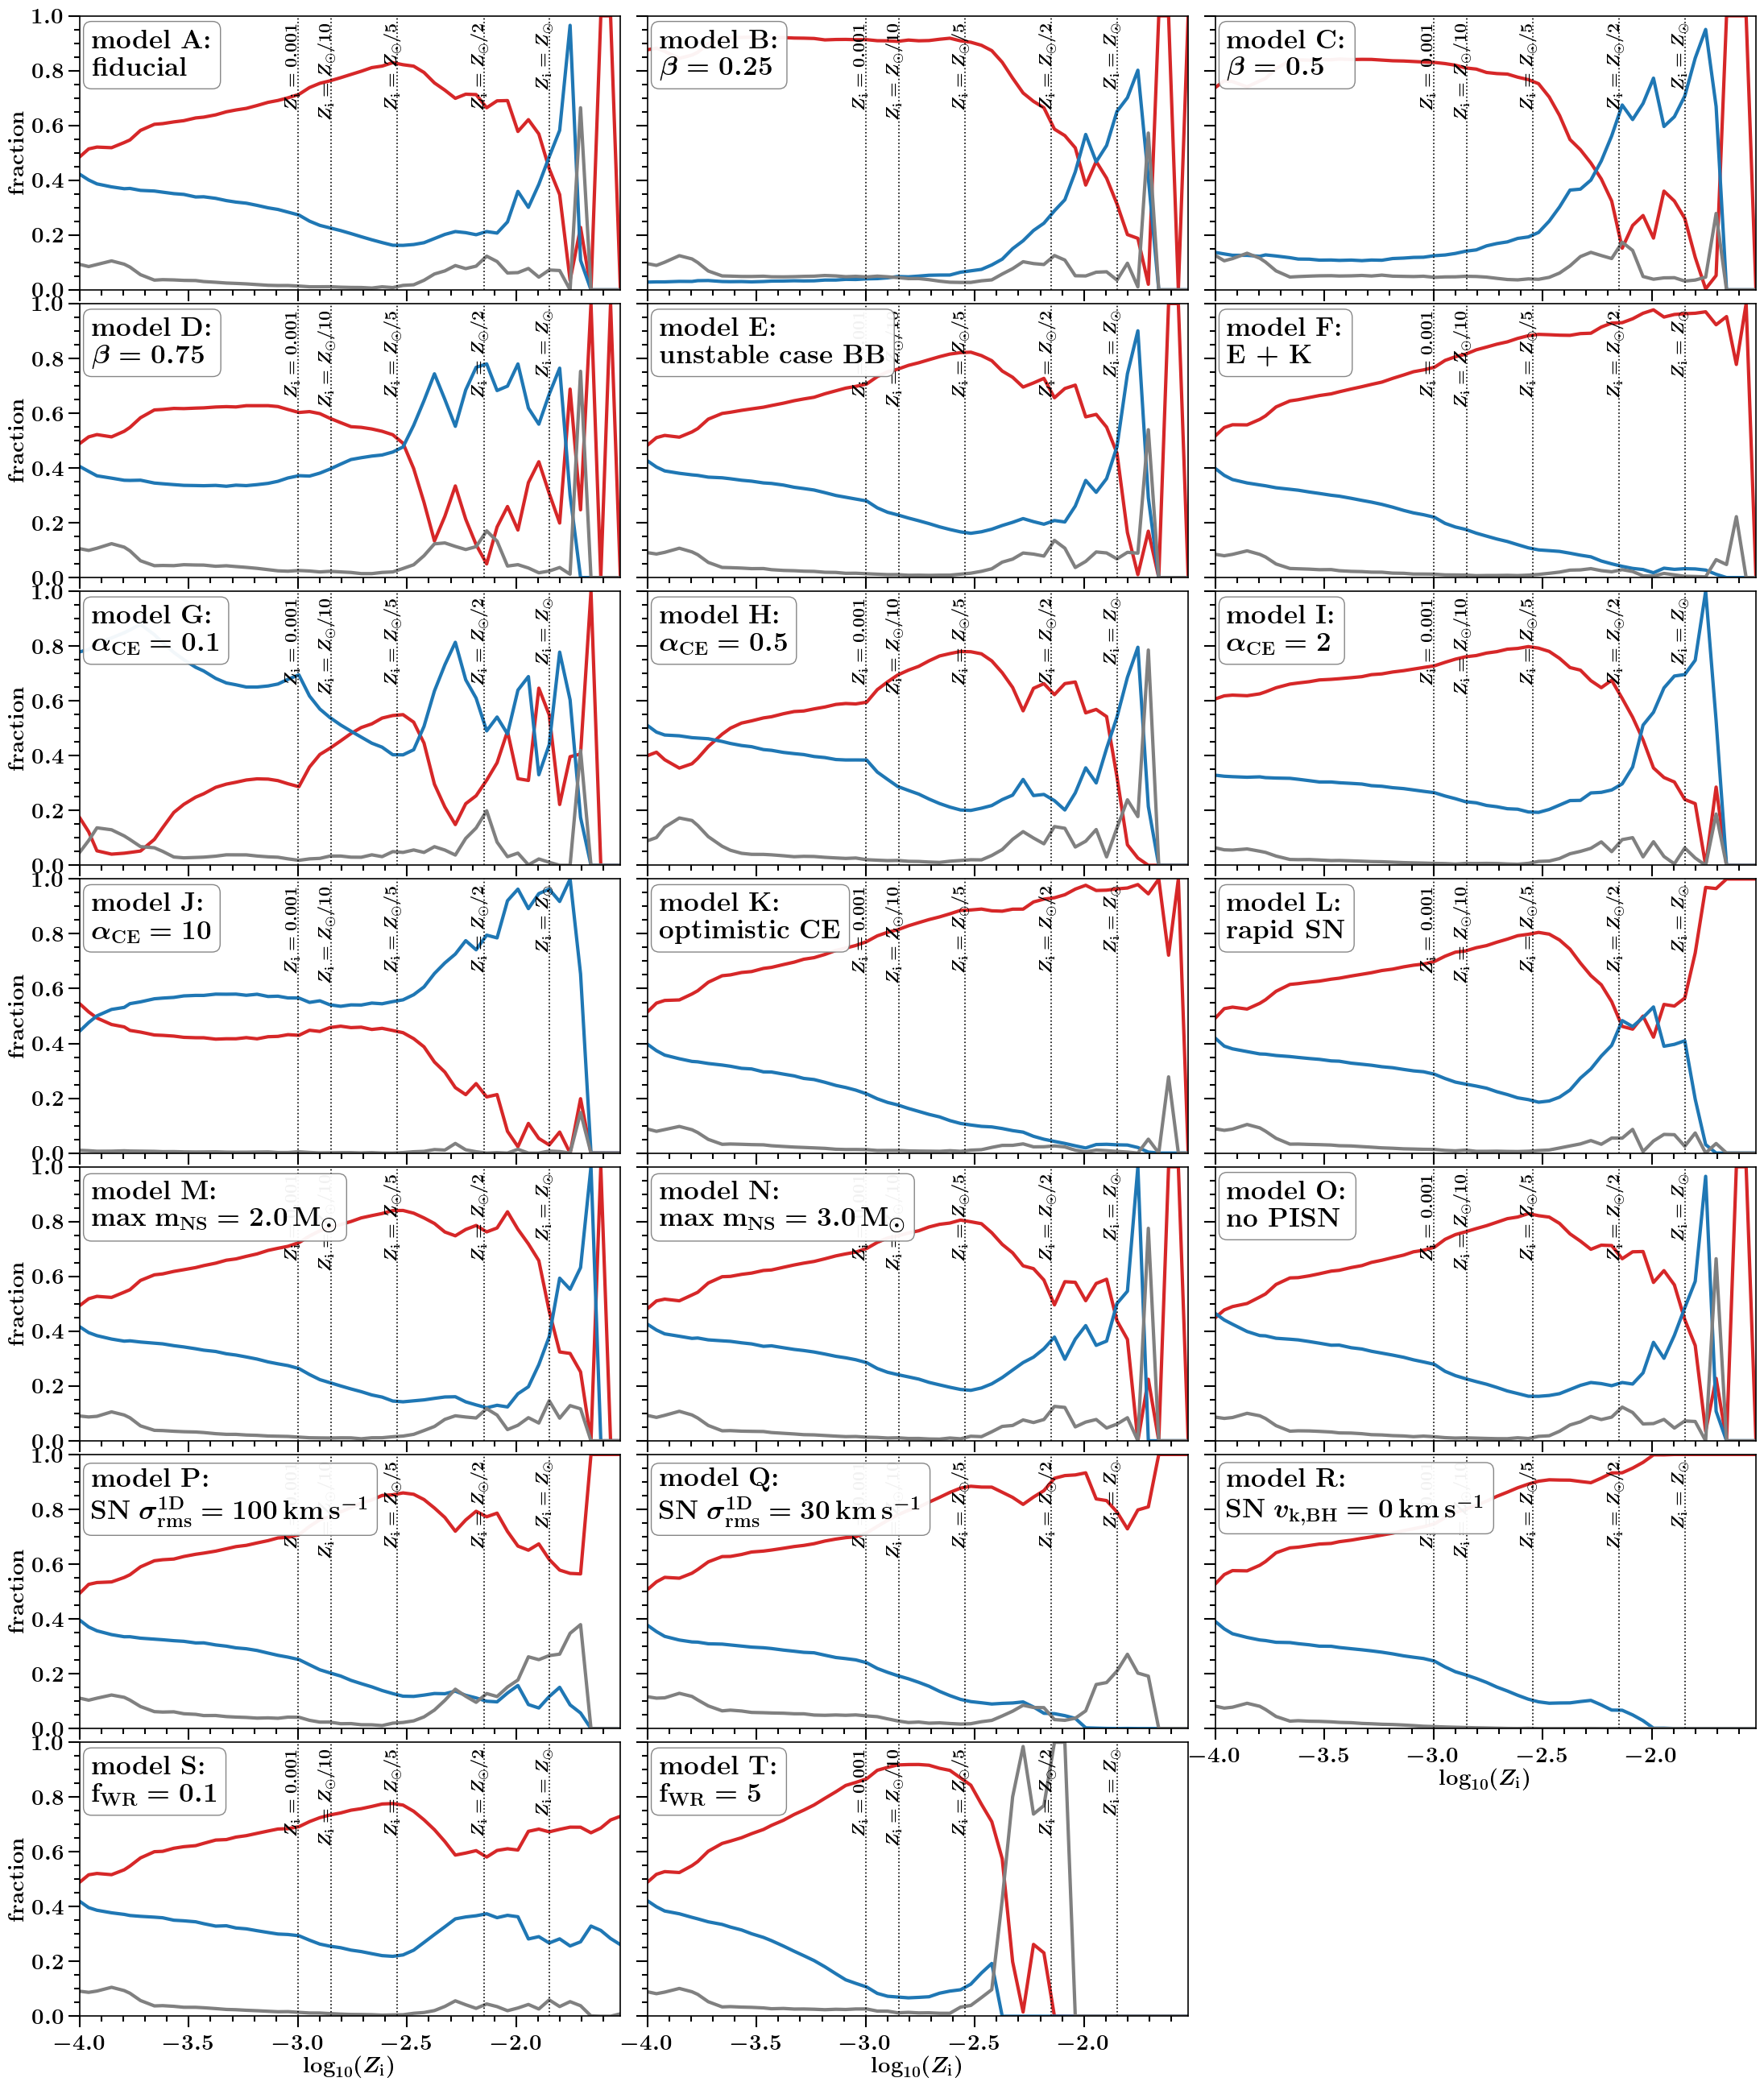

doing DCO type  BHNS


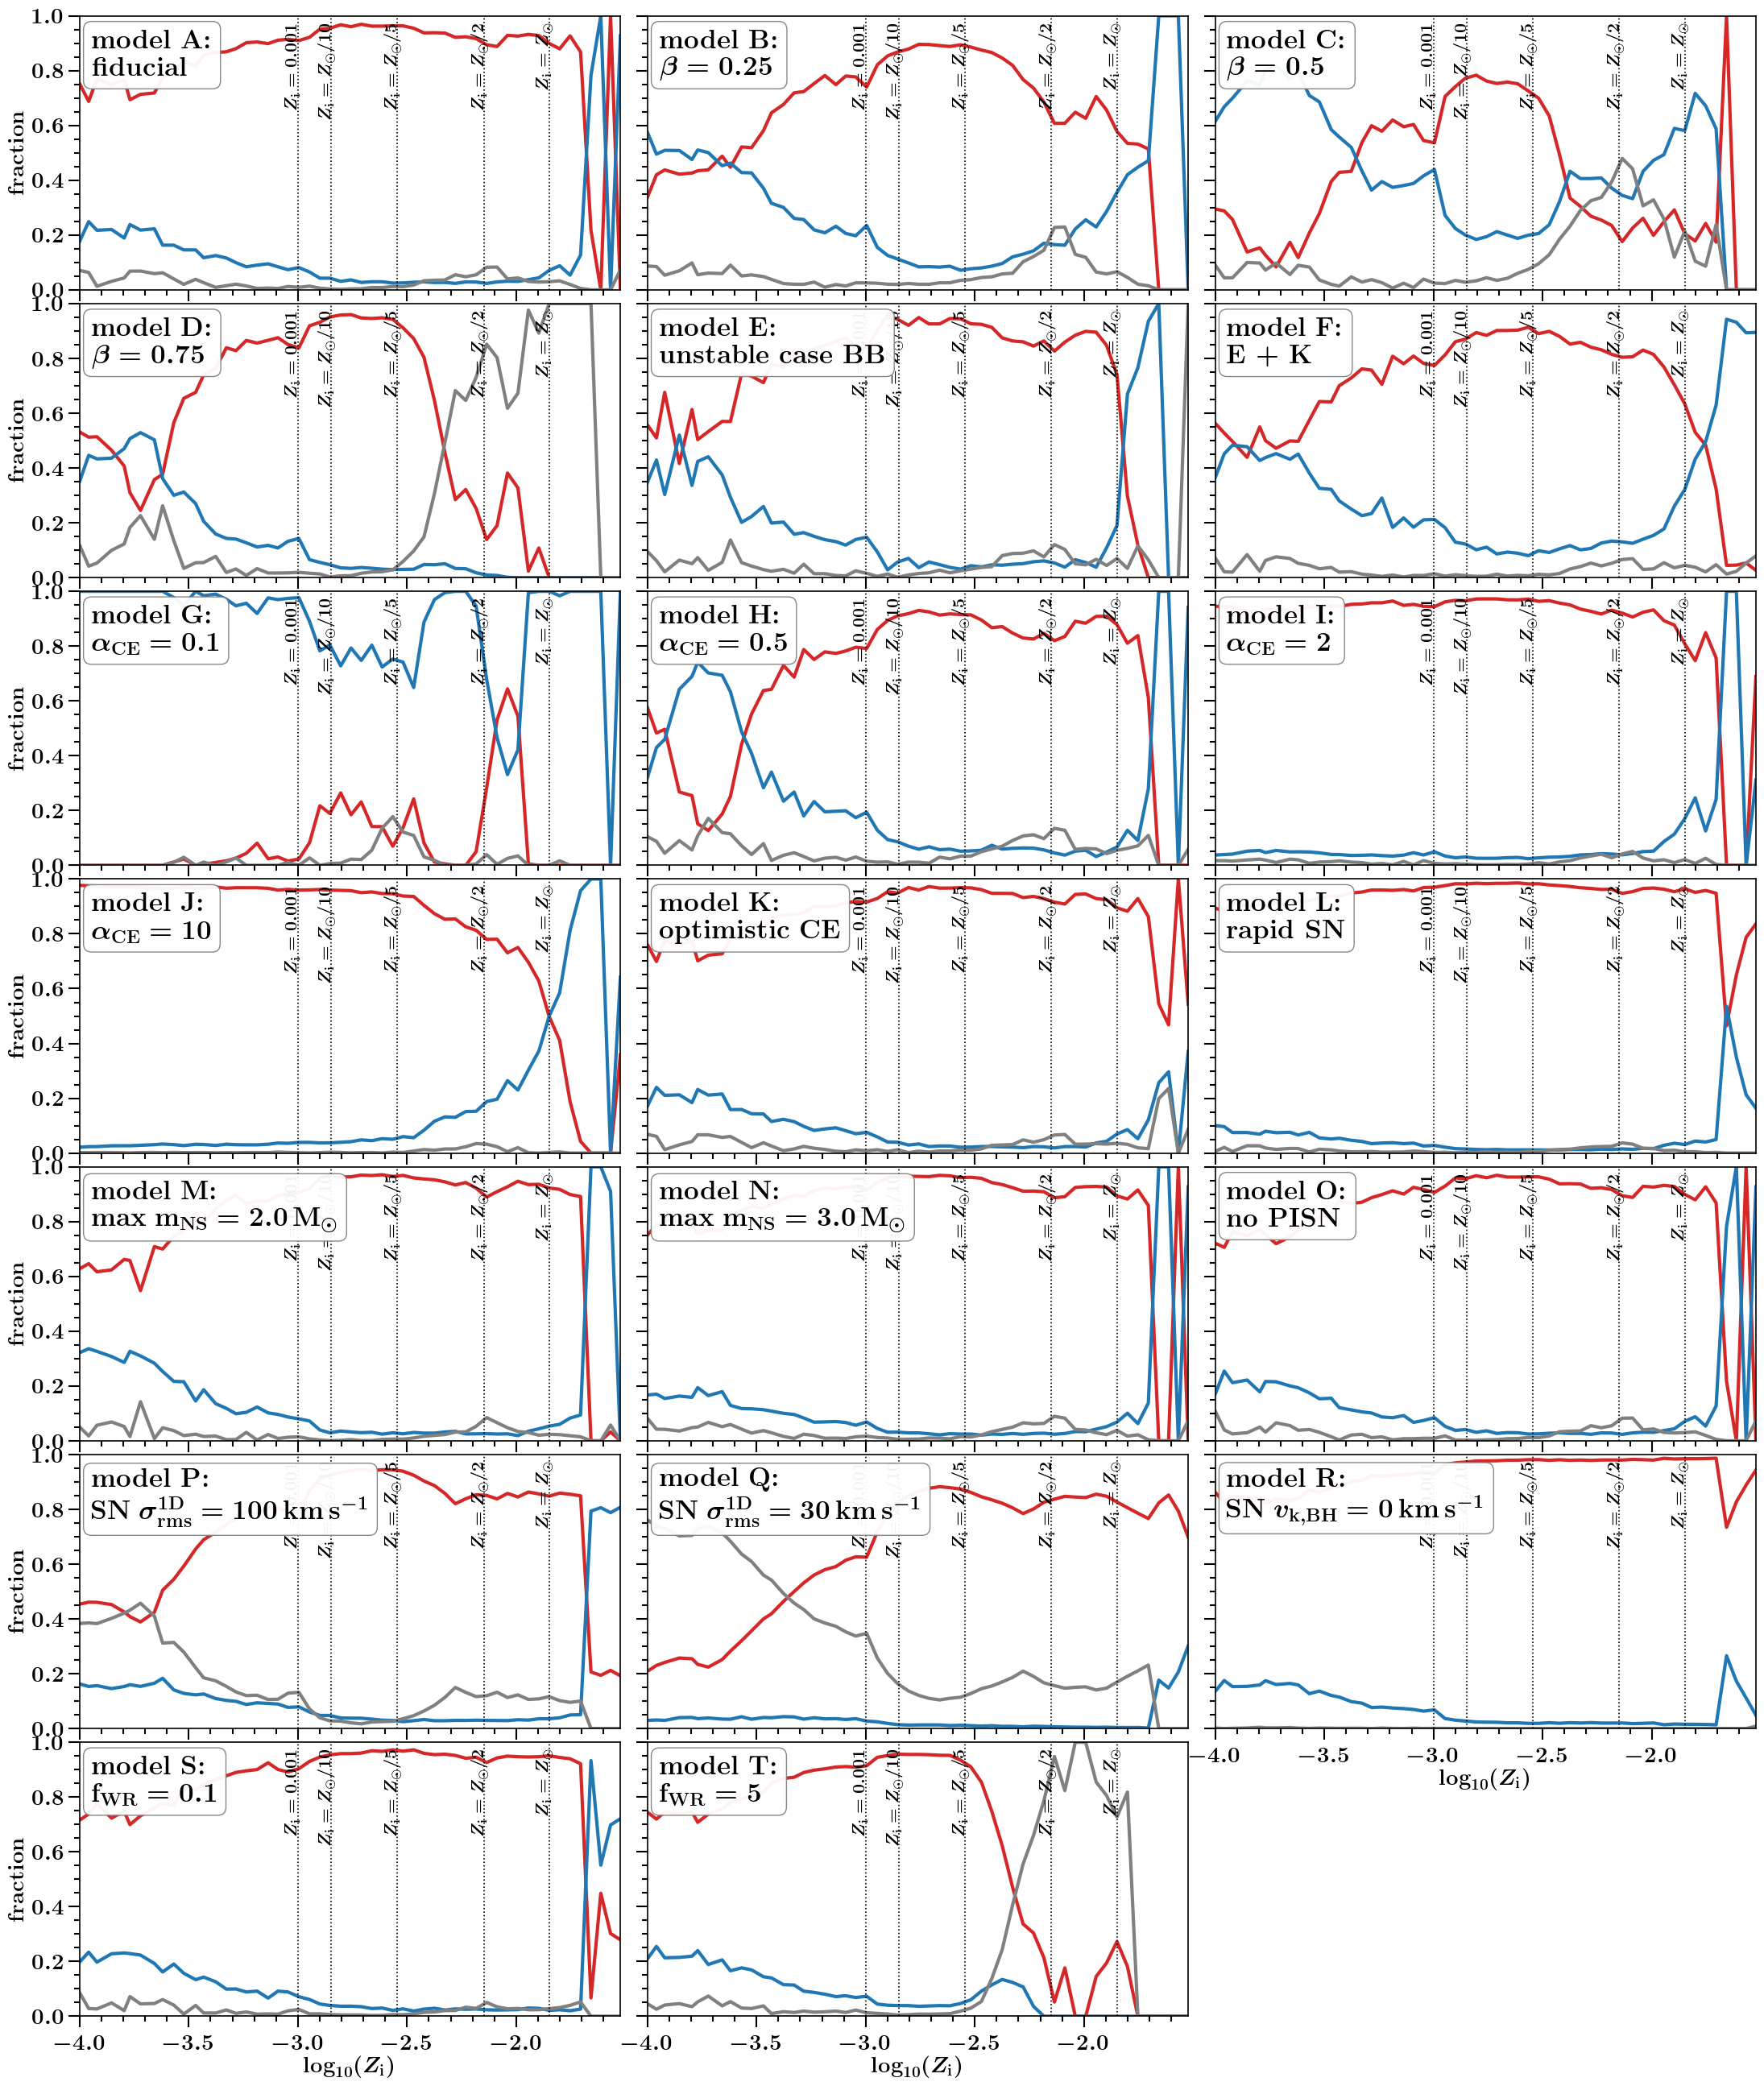

doing DCO type  BNS


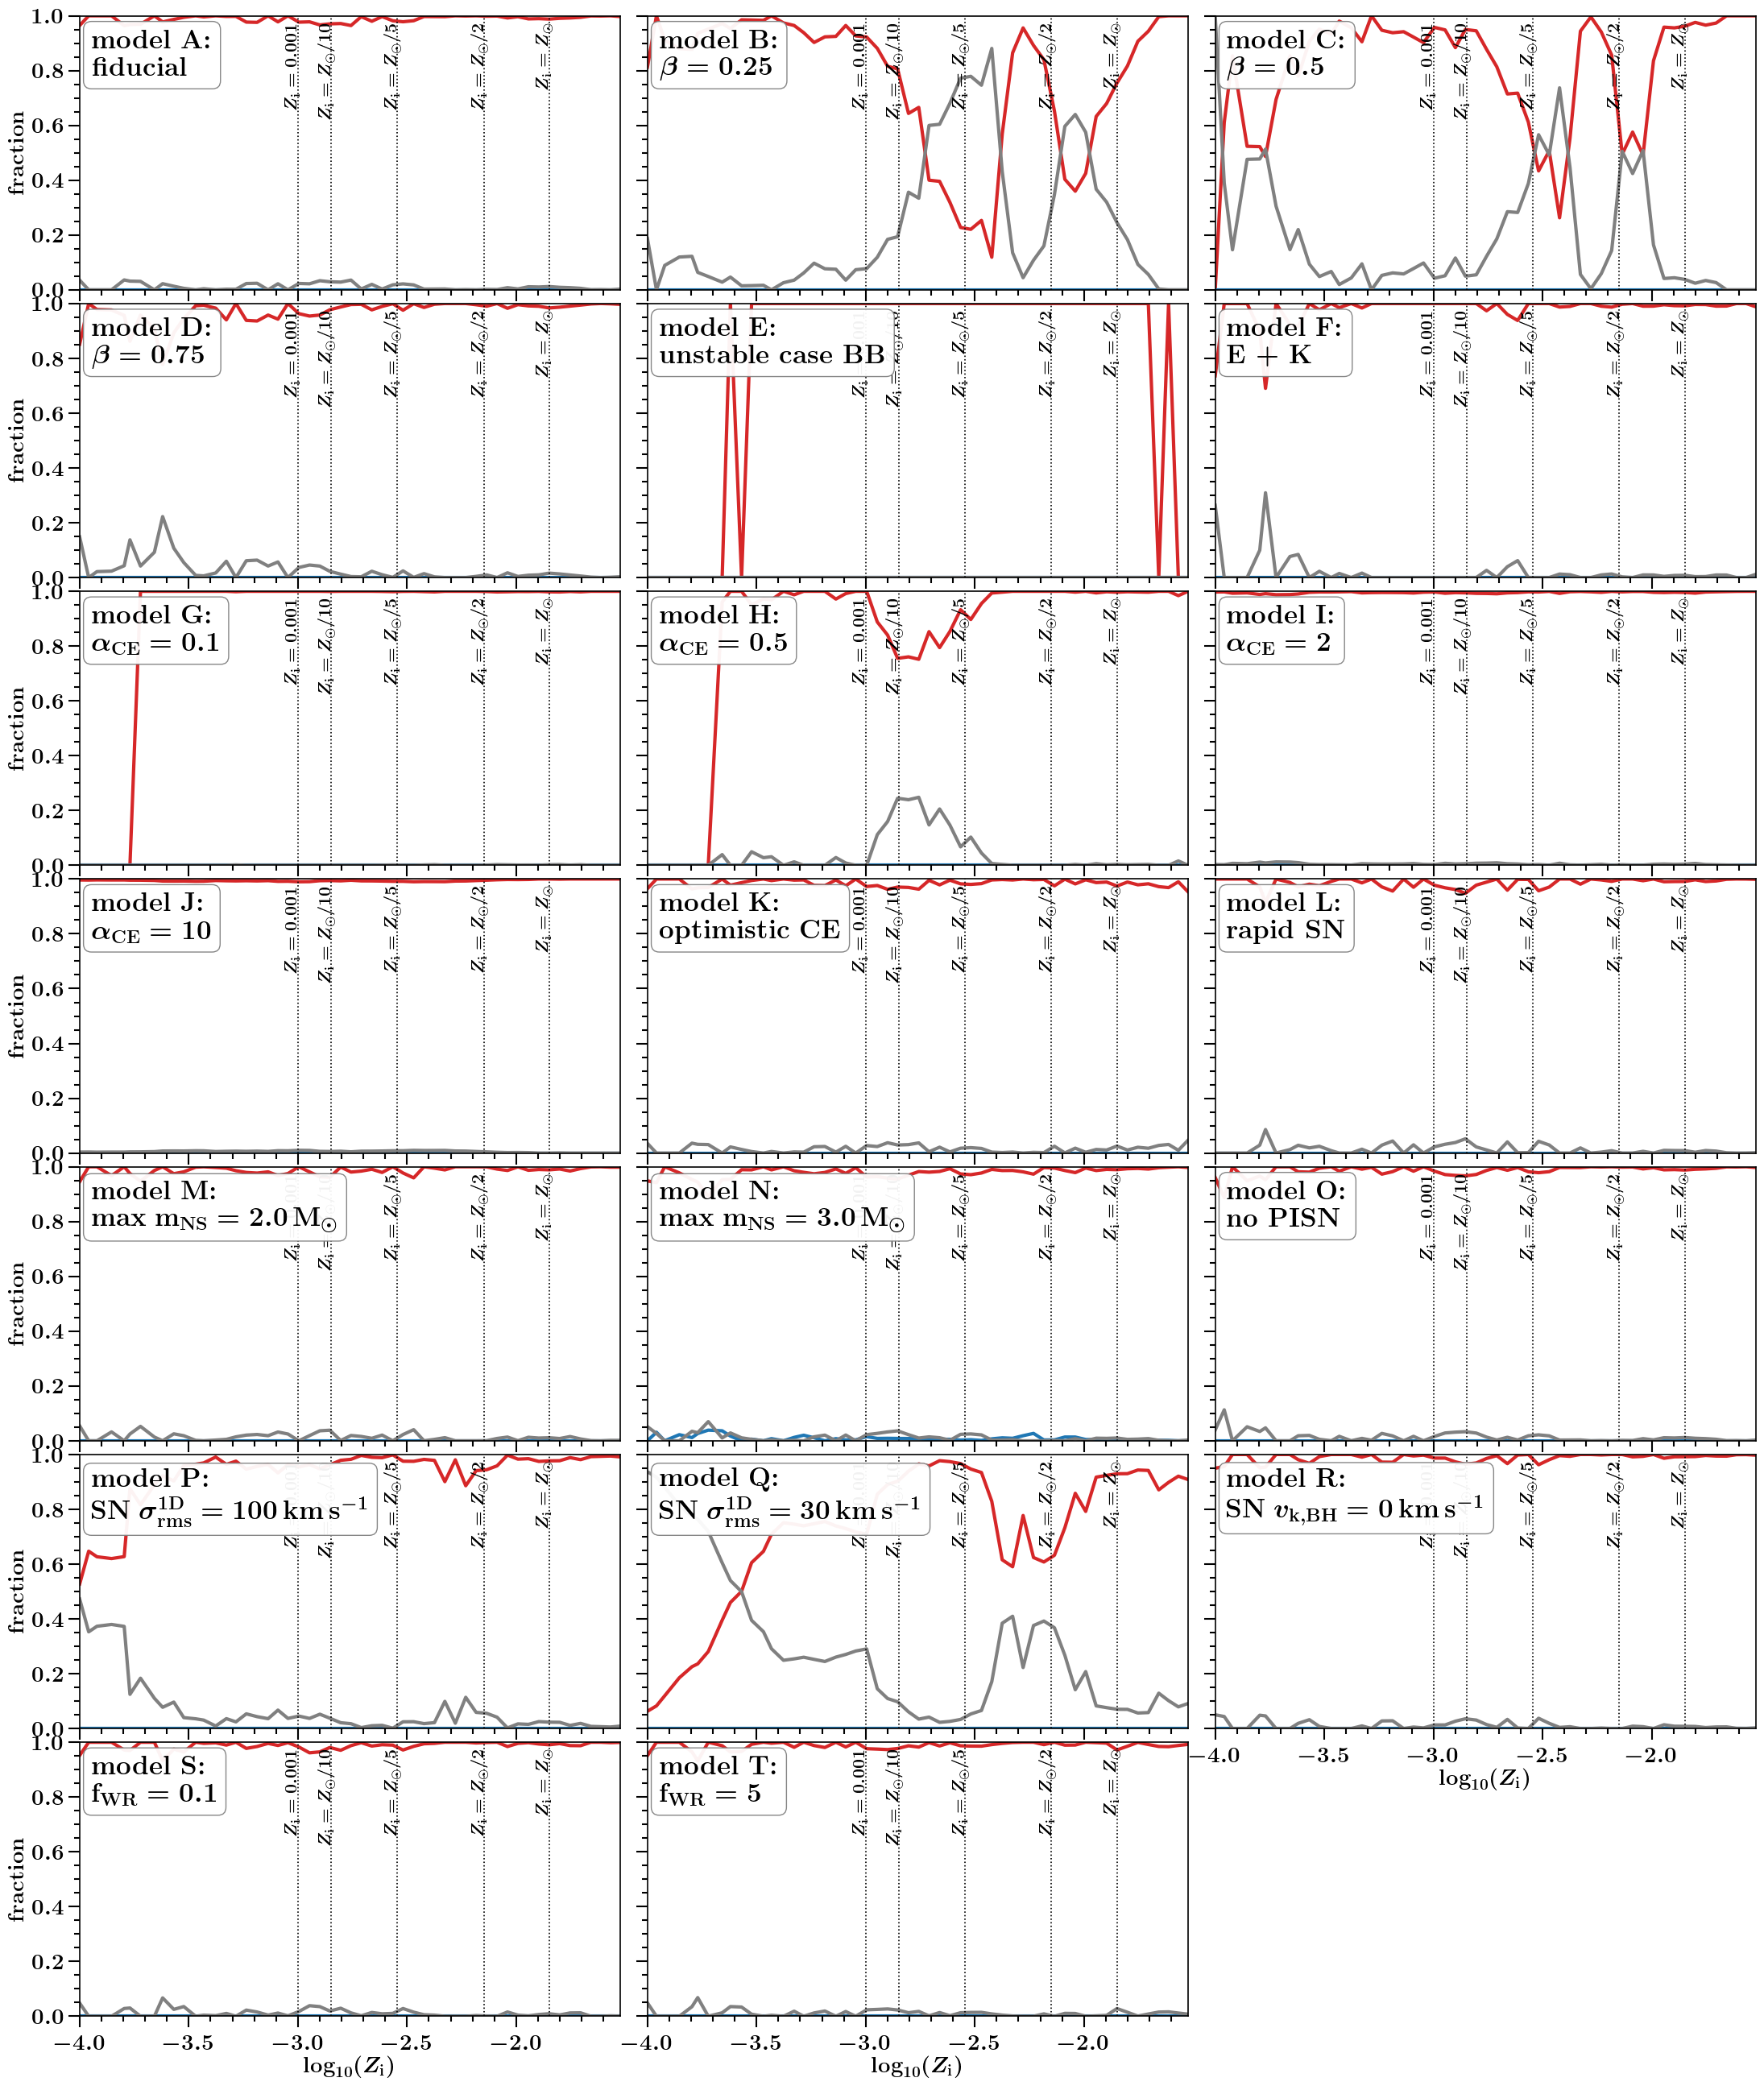

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import h5py as h5

sys.path.append('../../../common_code')

#Custom imports
# for color map
import seaborn as sns
# for reading datafiles 
import pandas as pd

# import script that has formation channel classification functions:
from PostProcessingScripts import * 


from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))



def load_grouped_formation_channels(
    df,
    bps_model,
    headerDict_Z_rev,
    include_vii_in_with_CE=False,
):
    """
    Group channels at the dataframe level.

    Returns a dict with:
      - with_CE
      - without_CE
      - other
      - total
    """

    ch_classic = df[f"{bps_model} {headerDict_Z_rev['classic']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_stable  = df[f"{bps_model} {headerDict_Z_rev['stable B no CEE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_vii     = df[f"{bps_model} {headerDict_Z_rev['vii']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_immed   = df[f"{bps_model} {headerDict_Z_rev['immediate CE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_double  = df[f"{bps_model} {headerDict_Z_rev['double-core CE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_other   = df[f"{bps_model} {headerDict_Z_rev['other']}  [Msun^{{-1}}]"].to_numpy(dtype=float)

    with_CE = ch_classic + ch_immed + ch_double
    if include_vii_in_with_CE:
        with_CE = with_CE + ch_vii

    without_CE = ch_stable
    other = ch_other

    total = with_CE + without_CE + other
    if not include_vii_in_with_CE:
        total = total + ch_vii

    return {
        "with_CE": with_CE,
        "without_CE": without_CE,
        "other": other,
        "total": total,
        "vii": ch_vii,
    }



def plotFormationChannelsGroupedSingle(
    axe,
    metallicities,
    grouped_rates,
    colorlist,
    labels,
    BPSmodelname='A',
    Ylim=3.85,
    DCOtype='BBH',
    plot_stacked=True,
    plot_fraction=False,
):
    """
    grouped_rates should be a list like:
      [with_CE, without_CE, other]
    """

    upperY = np.zeros(len(metallicities), dtype=float)
    lowerY = np.zeros(len(metallicities), dtype=float)

    total = np.zeros(len(metallicities), dtype=float)
    for rate in grouped_rates:
        total += np.asarray(rate, dtype=float)

    total_sum = np.sum(total)

    plotfactor_higher = False
    if plot_fraction is False:
        if (DCOtype == 'BNS') and (BPSmodelname in ["E", "H"]):
            plotfactor_higher = 10
        elif (DCOtype == 'BHNS') and (BPSmodelname in ["E", "G"]):
            plotfactor_higher = 10

    for ind_c, c_rate in enumerate(grouped_rates):
        c_rate = np.asarray(c_rate, dtype=float)

        if plot_fraction:
            fc_plot_rate = np.divide(
                c_rate,
                total,
                out=np.zeros_like(c_rate),
                where=(total > 0)
            )
        else:
            fc_plot_rate = c_rate * 1e5

        if plotfactor_higher is not False:
            fc_plot_rate = fc_plot_rate * plotfactor_higher

        upperY += fc_plot_rate

        percentage = 0.0 if total_sum == 0 else (np.sum(c_rate) / total_sum) * 100.0
        percentage_str = labels[ind_c] + ' ' + r'$%s$' % str(roundAndFormat1(percentage)) + r'\%'

        if plot_stacked:
            axe.fill_between(
                metallicities,
                lowerY,
                upperY,
                facecolor=colorlist[ind_c],
                lw=3,
                alpha=1,
                label=percentage_str
            )
        else:
            axe.plot(
                metallicities,
                fc_plot_rate,
                color=colorlist[ind_c],
                lw=3,
                alpha=1,
                label=percentage_str
            )

        lowerY += fc_plot_rate

    for zz_ind, zz in enumerate(metallicity_vlines_values_list):
        axe.plot([zz, zz], [0, Ylim + 1], c='k', lw=1.2, alpha=1, linestyle=':', zorder=100)
        axe.text(
            zz - 0.06,
            Ylim - 0.022,
            s=metallicity_vlines_text_list[zz_ind],
            fontsize=fs - 8.5,
            rotation=90,
            verticalalignment='top'
        )

    if DCOtype == 'BBH':
        x_box, y_box = 0.63, .4
    elif (DCOtype == 'BNS') and (BPSmodelname == 'G'):
        x_box, y_box = 0.63, .4
    else:
        x_box, y_box = 0.01, .47

    if plot_fraction is False:
        axe.legend(
            fontsize=14,
            ncol=2,
            bbox_to_anchor=(x_box, y_box),
            loc="lower left",
            borderaxespad=0.,
            frameon=False
        ).set_zorder(10000)

    axe.set_xlim(min(metallicities), max(metallicities))
    axe.set_ylim(0, Ylim)

    bbox_props = dict(boxstyle="round", fc="w", ec="0.5", alpha=0.95)
    axe.annotate(
        r'\textbf{model %s:}' % (BPSmodelname) + '\n' + alphabetPhysicalNameDict[BPSmodelname],
        xy=(0.022, .95),
        xycoords='axes fraction',
        fontsize=fs,
        weight='bold',
        ha='left',
        va="top",
        bbox=bbox_props,
        zorder=1E10
    )

    if plotfactor_higher is not False:
        axe.annotate(
            r'\textbf{%s}' % (plotfactor_higher) + r'$\times$',
            xy=(0.88, .15),
            xycoords='axes fraction',
            fontsize=fs + 5,
            weight='bold',
            ha='left',
            va="top",
            zorder=1E10
        )

    return axe




def plotGridFormationRatePerMetallicity_grouped(
    DCOtype='BBH',
    Ylim=10,
    csvPath=None,
    plot_stacked=True,
    plot_fraction=False,
    include_vii_in_with_CE=False,
):
    dictDCOtypeDCOlabel = {'BBH':'BHBH', 'BNS':'NSNS', 'BHNS':'BHNS', 'NSBH':'NSBH'}
    DCOname = dictDCOtypeDCOlabel[DCOtype]

    print('doing DCO type ', DCOtype)

    csv_file = f"{csvPath}/formation_channels_per_Z_hdf5weights_{DCOname}.csv"
    df = pd.read_csv(csv_file, index_col=0)

    BPSnameslist = list(string.ascii_uppercase)[0:nModels]
    log10metallicities = np.log10(np.asarray(metallicities_list))

    ncols, nrows = 3, 7
    f, axe = plt.subplots(
        ncols=ncols,
        nrows=nrows,
        figsize=(22,26),
        gridspec_kw={"width_ratios":1*np.ones(ncols), "height_ratios":1*np.ones(nrows)}
    )

    grouped_labels = ['with CE', 'without CE', 'other']
    grouped_colors = ['tab:red', 'tab:blue', 'gray']

    for ind_m, bps_model in enumerate(BPSnameslist):
        ii, jj = int(ind_m/ncols) % nrows, ind_m % ncols

        grouped = load_grouped_formation_channels(
            df=df,
            bps_model=bps_model,
            headerDict_Z_rev=headerDict_Z_rev,
            include_vii_in_with_CE=include_vii_in_with_CE,
        )

        grouped_rates = [
            grouped['with_CE'],
            grouped['without_CE'],
            grouped['other'],
        ]

        axe[ii, jj] = plotFormationChannelsGroupedSingle(
            axe=axe[ii, jj],
            metallicities=log10metallicities,
            grouped_rates=grouped_rates,
            colorlist=grouped_colors,
            labels=grouped_labels,
            BPSmodelname=bps_model,
            Ylim=Ylim,
            DCOtype=DCOtype,
            plot_stacked=plot_stacked,
            plot_fraction=plot_fraction,
        )

    fs_label = 20
    ylabel = r'$\eta \ \  [10^{-5}\ \rm{M}_{\odot}^{-1}]\  $'
    xlabel = r'$\log_{10}(Z_{\rm{i}})$'
    if plot_fraction is True:
        ylabel = r'$\textbf{fraction}  $'

    for ii in range(nrows-1):
        axe[ii,0] = layoutAxesNoXlabel(axe[ii,0], nameX=None, nameY=ylabel, fontsize=fs_label)
    axe[nrows-1,0] = layoutAxes(axe[nrows-1,0], nameX=xlabel, nameY=ylabel, fontsize=fs_label)

    for ii in range(nrows-1):
        axe[ii,1] = layoutAxesNoXandYlabel(axe[ii,1], nameX=None, nameY=None, fontsize=fs_label)
    axe[nrows-1,1] = layoutAxesNoYlabel(axe[nrows-1,1], nameX=xlabel, nameY='xx', fontsize=fs_label)

    for ii in range(nrows-2):
        axe[ii,2] = layoutAxesNoXandYlabel(axe[ii,2], nameX=None, nameY=None, fontsize=fs_label)

    axe[nrows-2,2] = layoutAxesNoYlabel(axe[nrows-2,2], nameX=xlabel, nameY=None, fontsize=fs_label)
    axe[nrows-1,2].axis('off')
    axe[nrows-2,2].set_zorder(100)

    for ii in range(nrows-2):
        axe[ii,2].tick_params(labelbottom=False, labelleft=False)
    for ii in range(nrows-1):
        axe[ii,1].tick_params(labelbottom=False, labelleft=False)
    for ii in range(nrows-1):
        axe[ii,0].tick_params(labelbottom=False)

    axe[nrows-1,1].tick_params(labelleft=False)
    axe[nrows-2,2].tick_params(labelleft=False)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.05, hspace=0.05)

    stack_str = 'stacked' if plot_stacked else 'notstacked'
    fract_str = '_fraction' if plot_fraction else '_yield'

    plt.show()
    plt.close()
    
    
    
# csvPath = '/Users/floorbroekgaarden/Projects/GitHub/Double-Compact-Object-Mergers/dataFiles/summary_data_Fig_1/'
csvPath = '/Users/floorbroekgaarden/Projects/GitHub/DCO_FormationChannels/dataFiles/data_Fig_1/'
# formation_channels_per_Z_hdf5weights_BHBH.csv
plotGridFormationRatePerMetallicity_grouped(
    DCOtype='BBH',
    Ylim=1,
    csvPath=csvPath,
    plot_stacked=False,
    plot_fraction=True,
    include_vii_in_with_CE=False,
)

plotGridFormationRatePerMetallicity_grouped(
    DCOtype='BHNS',
    Ylim=1,
    csvPath=csvPath,
    plot_stacked=False,
    plot_fraction=True,
    include_vii_in_with_CE=False,
)

plotGridFormationRatePerMetallicity_grouped(
    DCOtype='BNS',
    Ylim=1,
    csvPath=csvPath,
    plot_stacked=False,
    plot_fraction=True,
    include_vii_in_with_CE=False,
)

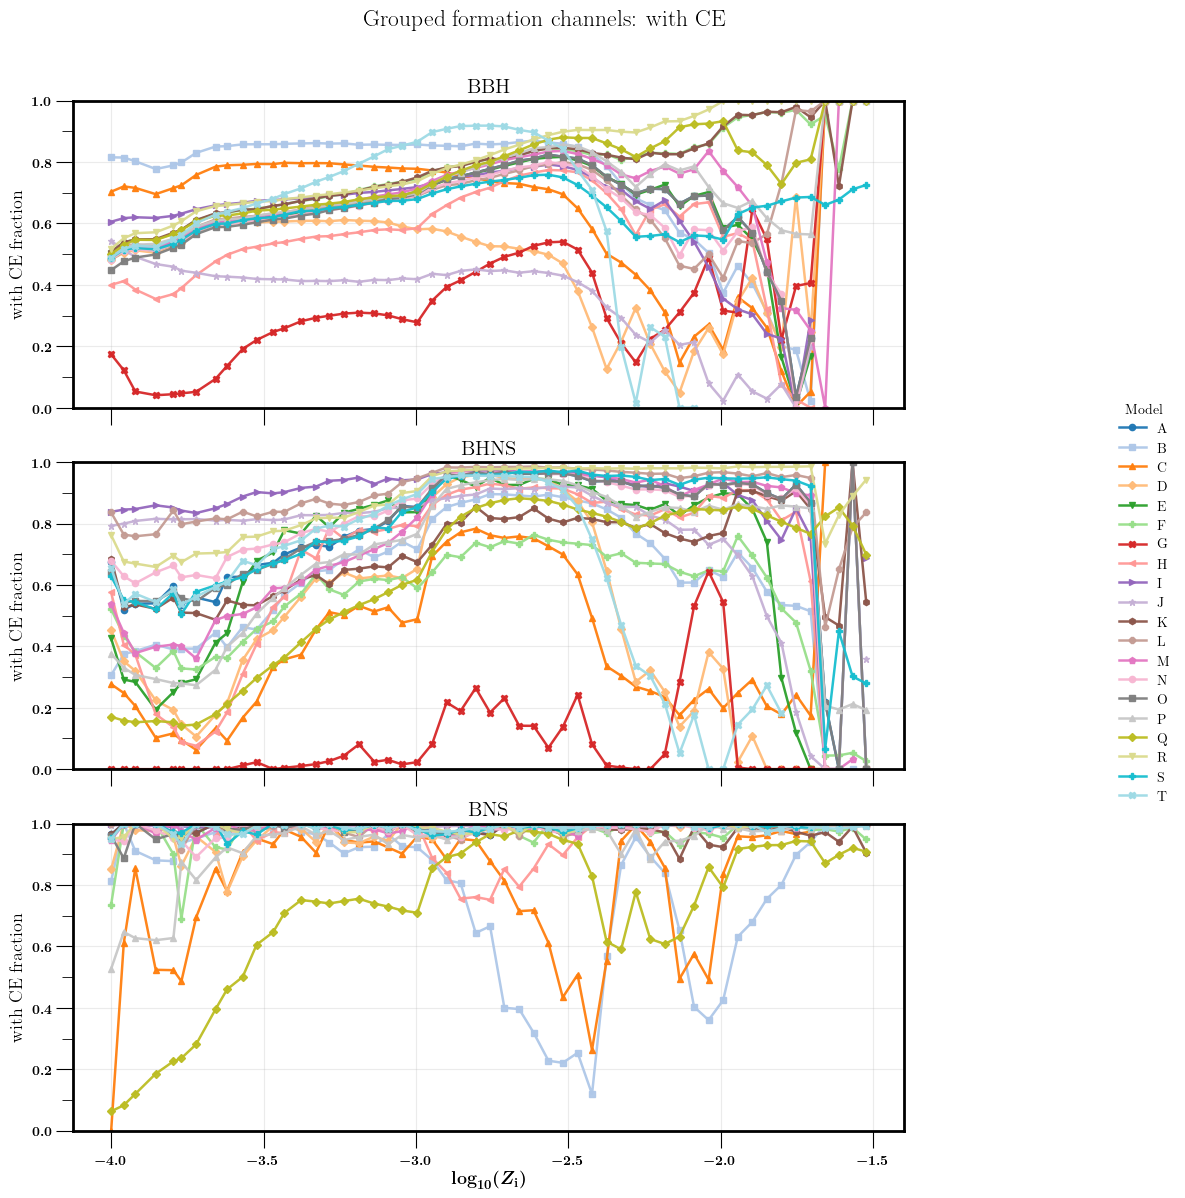

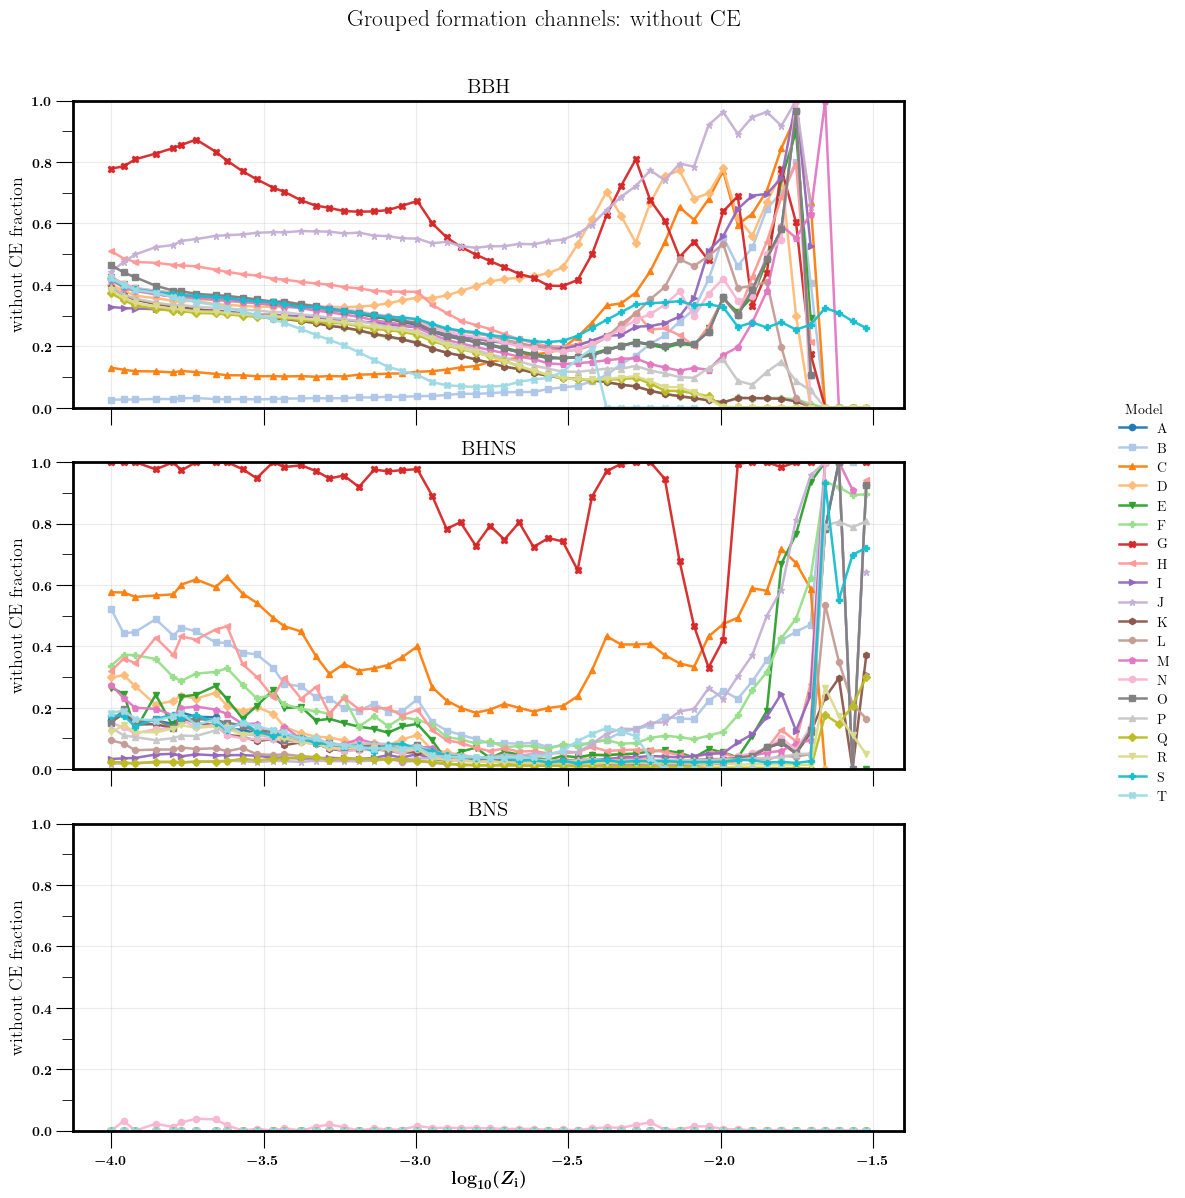

In [10]:
import os
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# assumes these already exist from your environment / PostProcessingScripts:
# - metallicities_list
# - headerDict_Z_rev
# - nModels
# - alphabetPhysicalNameDict   (optional, only if you want pretty labels)


def load_grouped_formation_channels(
    df,
    bps_model,
    headerDict_Z_rev,
    include_vii_in_with_CE=False,
):
    """
    Group channels at the dataframe level.

    Returns a dict with:
      - with_CE
      - without_CE
      - other
      - total
      - vii
    """

    ch_classic = df[f"{bps_model} {headerDict_Z_rev['classic']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_stable  = df[f"{bps_model} {headerDict_Z_rev['stable B no CEE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_vii     = df[f"{bps_model} {headerDict_Z_rev['vii']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_immed   = df[f"{bps_model} {headerDict_Z_rev['immediate CE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_double  = df[f"{bps_model} {headerDict_Z_rev['double-core CE']}  [Msun^{{-1}}]"].to_numpy(dtype=float)
    ch_other   = df[f"{bps_model} {headerDict_Z_rev['other']}  [Msun^{{-1}}]"].to_numpy(dtype=float)

    with_CE = ch_classic + ch_immed + ch_double
    if include_vii_in_with_CE:
        with_CE = with_CE + ch_vii

    without_CE = ch_stable
    other = ch_other

    total = with_CE + without_CE + other
    if not include_vii_in_with_CE:
        total = total + ch_vii

    return {
        "with_CE": with_CE,
        "without_CE": without_CE,
        "other": other,
        "total": total,
        "vii": ch_vii,
    }


def get_grouped_fraction_or_yield(grouped, grouped_key="with_CE", plot_fraction=True):
    """
    Returns the y-values to plot for one grouped channel.
    """
    y = np.asarray(grouped[grouped_key], dtype=float)
    total = np.asarray(grouped["total"], dtype=float)

    if plot_fraction:
        yplot = np.divide(
            y,
            total,
            out=np.full_like(y, np.nan, dtype=float),
            where=(total > 0)
        )
    else:
        yplot = y * 1e5

    return yplot, total


def mask_low_total_points(yplot, total, min_total=0.0):
    """
    Mask points where the total efficiency/rate is too small.
    Useful for BNS where tiny totals can create noisy fractions.
    """
    ymasked = np.array(yplot, copy=True)
    ymasked[total <= min_total] = np.nan
    return ymasked


def plot_all_models_grouped_threepanels(
    csvPath,
    grouped_key="with_CE",          # 'with_CE', 'without_CE', or 'other'
    include_vii_in_with_CE=False,
    plot_fraction=True,
    min_total_mask=None,            # e.g. 1e-12 or 0.0; set None for no masking
    models_to_plot=None,            # default: A... according to nModels
    figsize=(10, 12),
    savefile=None,
):
    """
    One figure with 3 panels:
      - BBH
      - BHNS
      - BNS

    In each panel all models are overlaid.
    """

    dictDCOtypeDCOlabel = {
        'BBH': 'BHBH',
        'BHNS': 'BHNS',
        'BNS': 'NSNS',
    }

    dco_order = ['BBH', 'BHNS', 'BNS']
    log10metallicities = np.log10(np.asarray(metallicities_list, dtype=float))

    if models_to_plot is None:
        models_to_plot = list(string.ascii_uppercase[:nModels])

    # style setup
    color_cycle = plt.cm.tab20(np.linspace(0, 1, max(len(models_to_plot), 3)))
    marker_cycle = ['o', 's', '^', 'D', 'v', 'P', 'X', '<', '>', '*', 'h', '8', 'p']

    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=figsize,
        sharex=True,
        sharey=plot_fraction,
    )

    if grouped_key == "with_CE":
        main_title = "with CE"
    elif grouped_key == "without_CE":
        main_title = "without CE"
    else:
        main_title = "other"

    for i_dco, DCOtype in enumerate(dco_order):
        ax = axes[i_dco]

        csv_file = os.path.join(
            csvPath,
            f"formation_channels_per_Z_hdf5weights_{dictDCOtypeDCOlabel[DCOtype]}.csv"
        )
        df = pd.read_csv(csv_file, index_col=0)

        for i_model, bps_model in enumerate(models_to_plot):
            grouped = load_grouped_formation_channels(
                df=df,
                bps_model=bps_model,
                headerDict_Z_rev=headerDict_Z_rev,
                include_vii_in_with_CE=include_vii_in_with_CE,
            )

            yplot, total = get_grouped_fraction_or_yield(
                grouped,
                grouped_key=grouped_key,
                plot_fraction=plot_fraction,
            )

            if min_total_mask is not None:
                yplot = mask_low_total_points(yplot, total, min_total=min_total_mask)

            label = bps_model
            # optional prettier label:
            # if bps_model in alphabetPhysicalNameDict:
            #     label = f"{bps_model}: {alphabetPhysicalNameDict[bps_model]}"

            ax.plot(
                log10metallicities,
                yplot,
                lw=1.8,
                marker=marker_cycle[i_model % len(marker_cycle)],
                ms=4.5,
                color=color_cycle[i_model % len(color_cycle)],
                alpha=0.95,
                label=label,
            )

        ax.set_title(DCOtype, fontsize=15)
        ax.grid(True, alpha=0.25)

        if plot_fraction:
            ax.set_ylim(0, 1.0)
            ax.yaxis.set_major_locator(MultipleLocator(0.2))
            ax.yaxis.set_minor_locator(MultipleLocator(0.1))
            ax.set_ylabel(f"{main_title} fraction", fontsize=13)
        else:
            ax.set_ylabel(r'$\eta \,[10^{-5}\,M_\odot^{-1}]$', fontsize=13)

    axes[-1].set_xlabel(r'$\log_{10}(Z_{\rm i})$', fontsize=13)

    # Put legend outside
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False,
        ncol=1,
        fontsize=10,
        title="Model"
    )

    fig.suptitle(f"Grouped formation channels: {main_title}", fontsize=17, y=0.995)
    fig.tight_layout(rect=[0, 0, 0.84, 0.98])

    if savefile is not None:
        fig.savefig(savefile, bbox_inches="tight", dpi=300)

    plt.show()
    return fig, axes


csvPath = '/Users/floorbroekgaarden/Projects/GitHub/DCO_FormationChannels/dataFiles/data_Fig_1/'

fig, axes = plot_all_models_grouped_threepanels(
    csvPath=csvPath,
    grouped_key="with_CE",
    include_vii_in_with_CE=False,
    plot_fraction=True,
    min_total_mask=0.0,   # or try e.g. 1e-12 if needed
    figsize=(11, 12),
    savefile="all_models_withCE_threepanels.pdf",
)

fig, axes = plot_all_models_grouped_threepanels(
    csvPath=csvPath,
    grouped_key="without_CE",
    include_vii_in_with_CE=False,
    plot_fraction=True,
    min_total_mask=0.0,
    figsize=(11, 12),
    savefile="all_models_withoutCE_threepanels.pdf",
)

fig, axes = plot_all_models_grouped_threepanels(
    csvPath=csvPath,
    grouped_key="other",
    include_vii_in_with_CE=False,
    plot_fraction=True,
    min_total_mask=0.0,
    figsize=(11, 12),
    savefile="all_models_other_threepanels.pdf",
)